<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Benefits_of_Greenhouse_Effect_at_Night_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)


In [7]:
"""Install and verify the greenhouse-night visualization environment.
"""

import importlib
import shutil
import subprocess
import sys
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_PACKAGES: Final[bool] = True
SHOW_CUPY_CONFIG: Final[bool] = False
MPL_DPI: Final[int] = 250

REQUIRED_PACKAGES: Final[tuple[str, ...]] = (
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "sympy",
    "cupy-cuda12x",
)

# =============================================================================
# INSTALLATION AND BACKEND CHECKS
# =============================================================================


def run_command(command: list[str]) -> None:
    """Run a shell command with a readable echo."""
    print("$ " + " ".join(command))
    subprocess.check_call(command)


def install_with_uv(packages: tuple[str, ...]) -> None:
    """Install packages using uv pip, installing uv first when needed."""
    if shutil.which("uv") is None:
        run_command([sys.executable, "-m", "pip", "install", "-q", "uv"])

    uv_executable = shutil.which("uv")
    if uv_executable is None:
        command = [sys.executable, "-m", "uv", "pip", "install", "--system", "-q"]
    else:
        command = [uv_executable, "pip", "install", "--system", "-q"]

    run_command(command + list(packages))


def import_version(module_name: str) -> str:
    """Return the module version string when available."""
    module = importlib.import_module(module_name)
    return str(getattr(module, "__version__", "unknown"))


def check_cupy() -> tuple[bool, str]:
    """Return whether CuPy can see a CUDA device and a diagnostic string."""
    try:
        import cupy as cp

        device_count = cp.cuda.runtime.getDeviceCount()
        if device_count < 1:
            return False, "CuPy imported, although no CUDA device was found."
        device = cp.cuda.Device(0)
        props = cp.cuda.runtime.getDeviceProperties(device.id)
        name = props["name"].decode("utf-8")
        return True, f"CuPy active on CUDA device 0: {name}"
    except Exception as exc:  # noqa: BLE001
        return False, f"CuPy unavailable, using CPU paths where needed: {exc}"


def main() -> None:
    """Install packages and print environment diagnostics."""
    if INSTALL_PACKAGES:
        install_with_uv(REQUIRED_PACKAGES)

    import matplotlib as mpl

    mpl.rcParams["figure.dpi"] = MPL_DPI
    mpl.rcParams["savefig.dpi"] = MPL_DPI
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["mathtext.fontset"] = "cm"

    print("\nPackage versions")
    for module_name in ("numpy", "pandas", "matplotlib", "scipy", "sympy"):
        print(f"  {module_name:10s}: {import_version(module_name)}")

    cupy_ready, cupy_message = check_cupy()
    print(f"\nGPU backend: {cupy_message}")

    if cupy_ready and SHOW_CUPY_CONFIG:
        import cupy as cp

        cp.show_config()

    print("\nPaste the remaining downloaded cells below this one in Colab.")


if __name__ == "__main__":
    main()

$ /usr/local/bin/uv pip install --system -q numpy pandas matplotlib scipy sympy cupy-cuda12x

Package versions
  numpy     : 2.0.2
  pandas    : 2.2.2
  matplotlib: 3.10.0
  scipy     : 1.16.3
  sympy     : 1.14.0

GPU backend: CuPy active on CUDA device 0: Tesla T4

Paste the remaining downloaded cells below this one in Colab.


Scenario summary
                     scenario  tau_lw  air_emissivity  L_down_W_m2  min_temp_K  min_temp_C  mean_net_flux_W_m2  cooling_rate_K_per_hour
           very dry clear sky  0.2000          0.1813      67.8134    285.8059     12.6559           -324.5938                  -0.4328
baseline nocturnal greenhouse  0.7500          0.5276     197.3892    287.7159     14.5659           -205.2317                  -0.2737
   humid infrared-thick night  1.2500          0.7135     266.9207    288.7404     15.5904           -141.2082                  -0.1883
cloud-enhanced longwave night  1.9500          0.8577     320.8778    289.5352     16.3852            -91.5385                  -0.1221


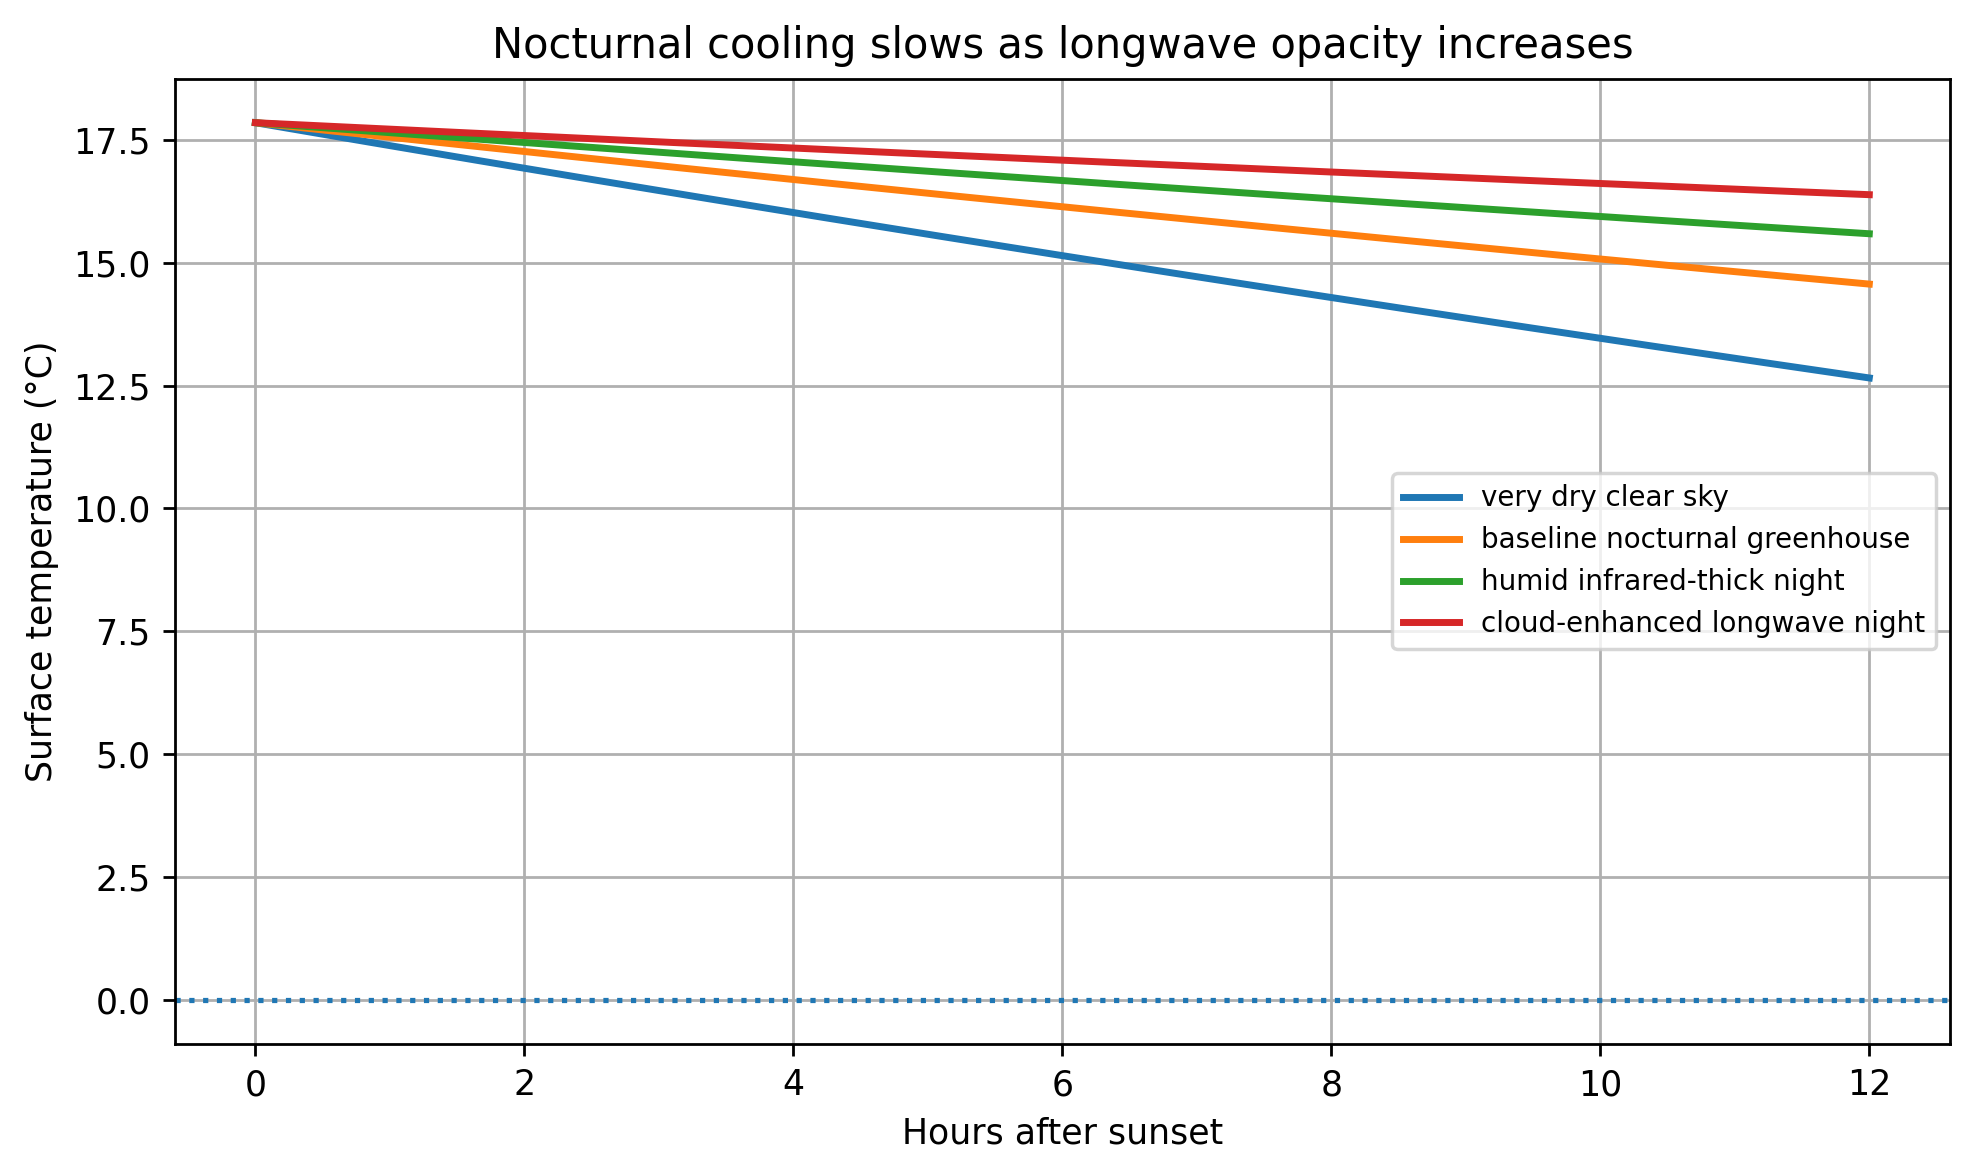

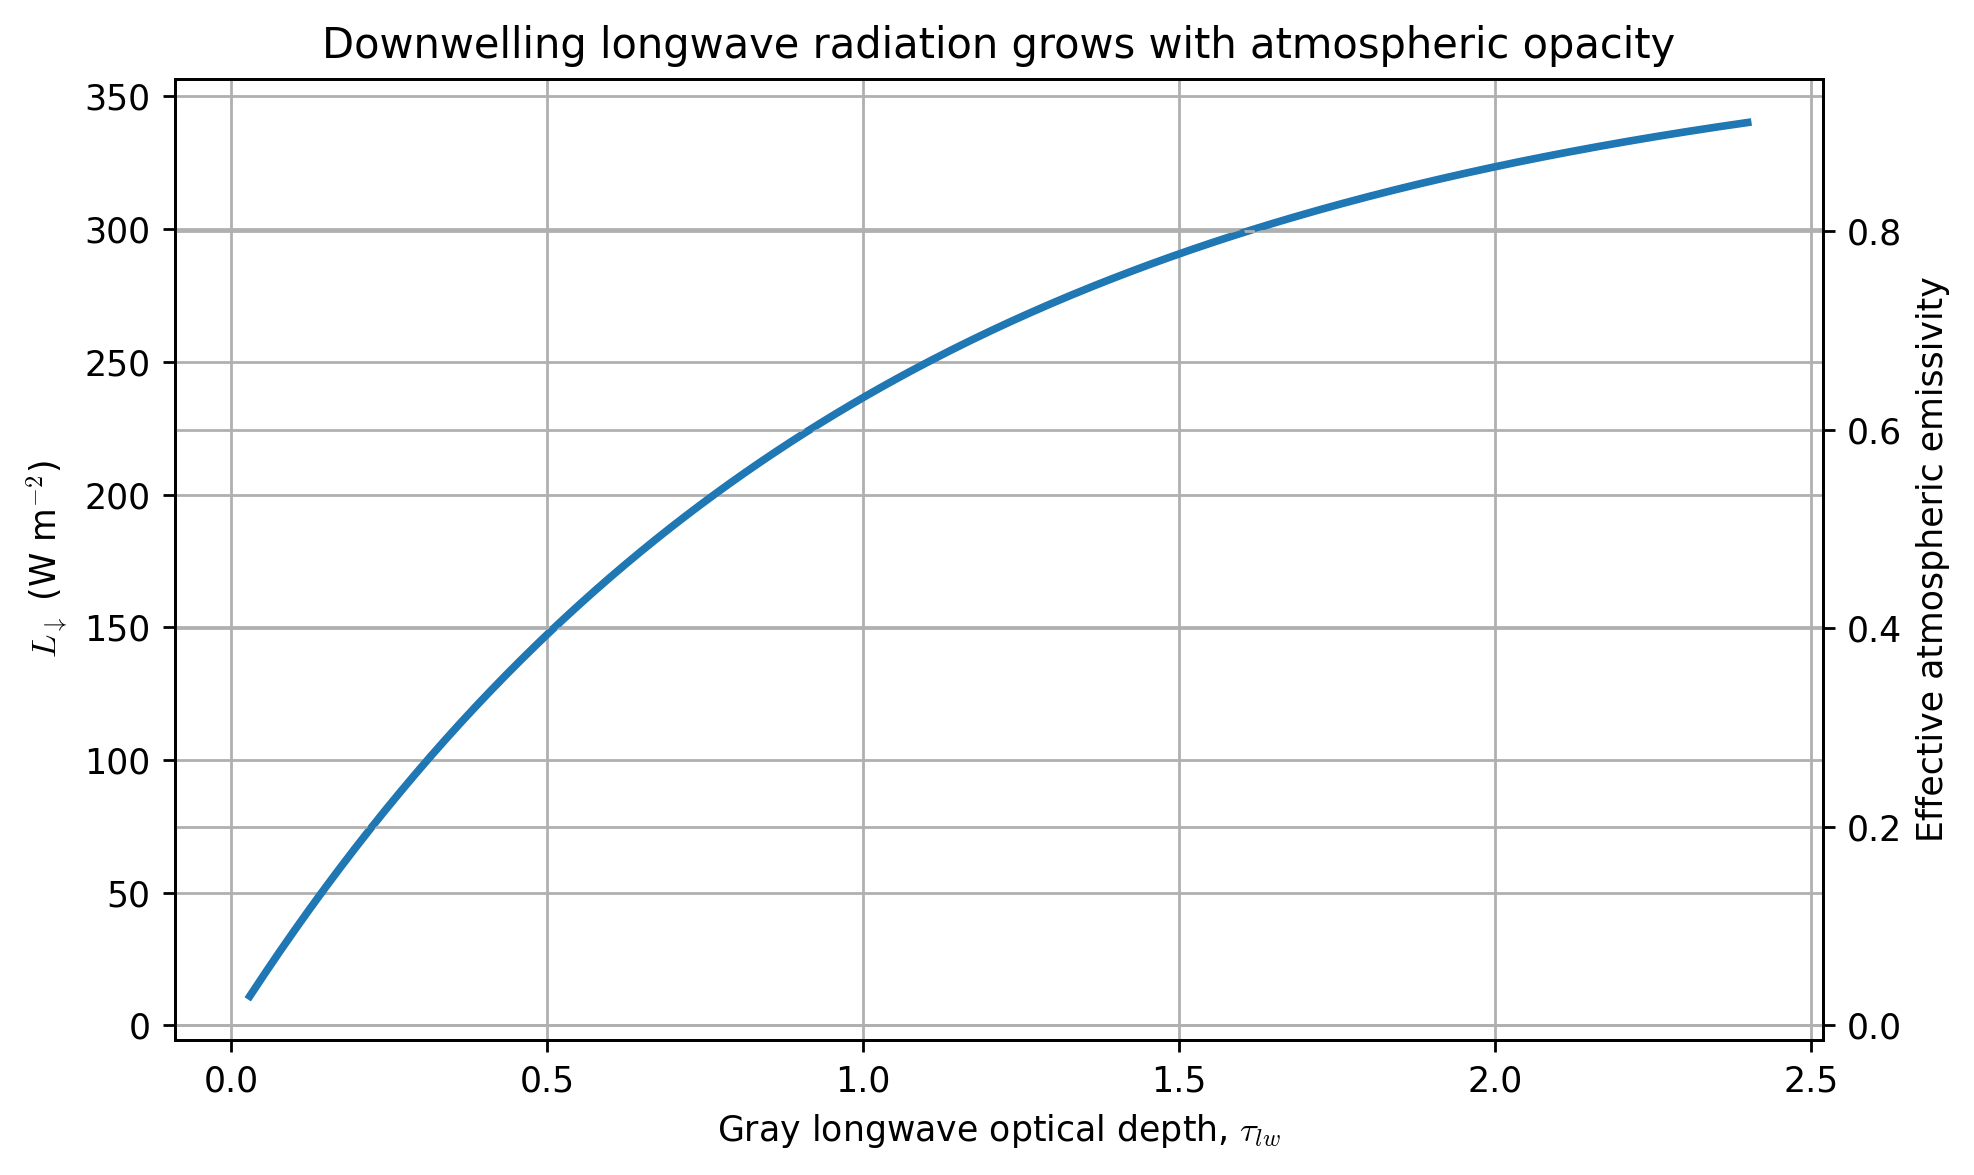

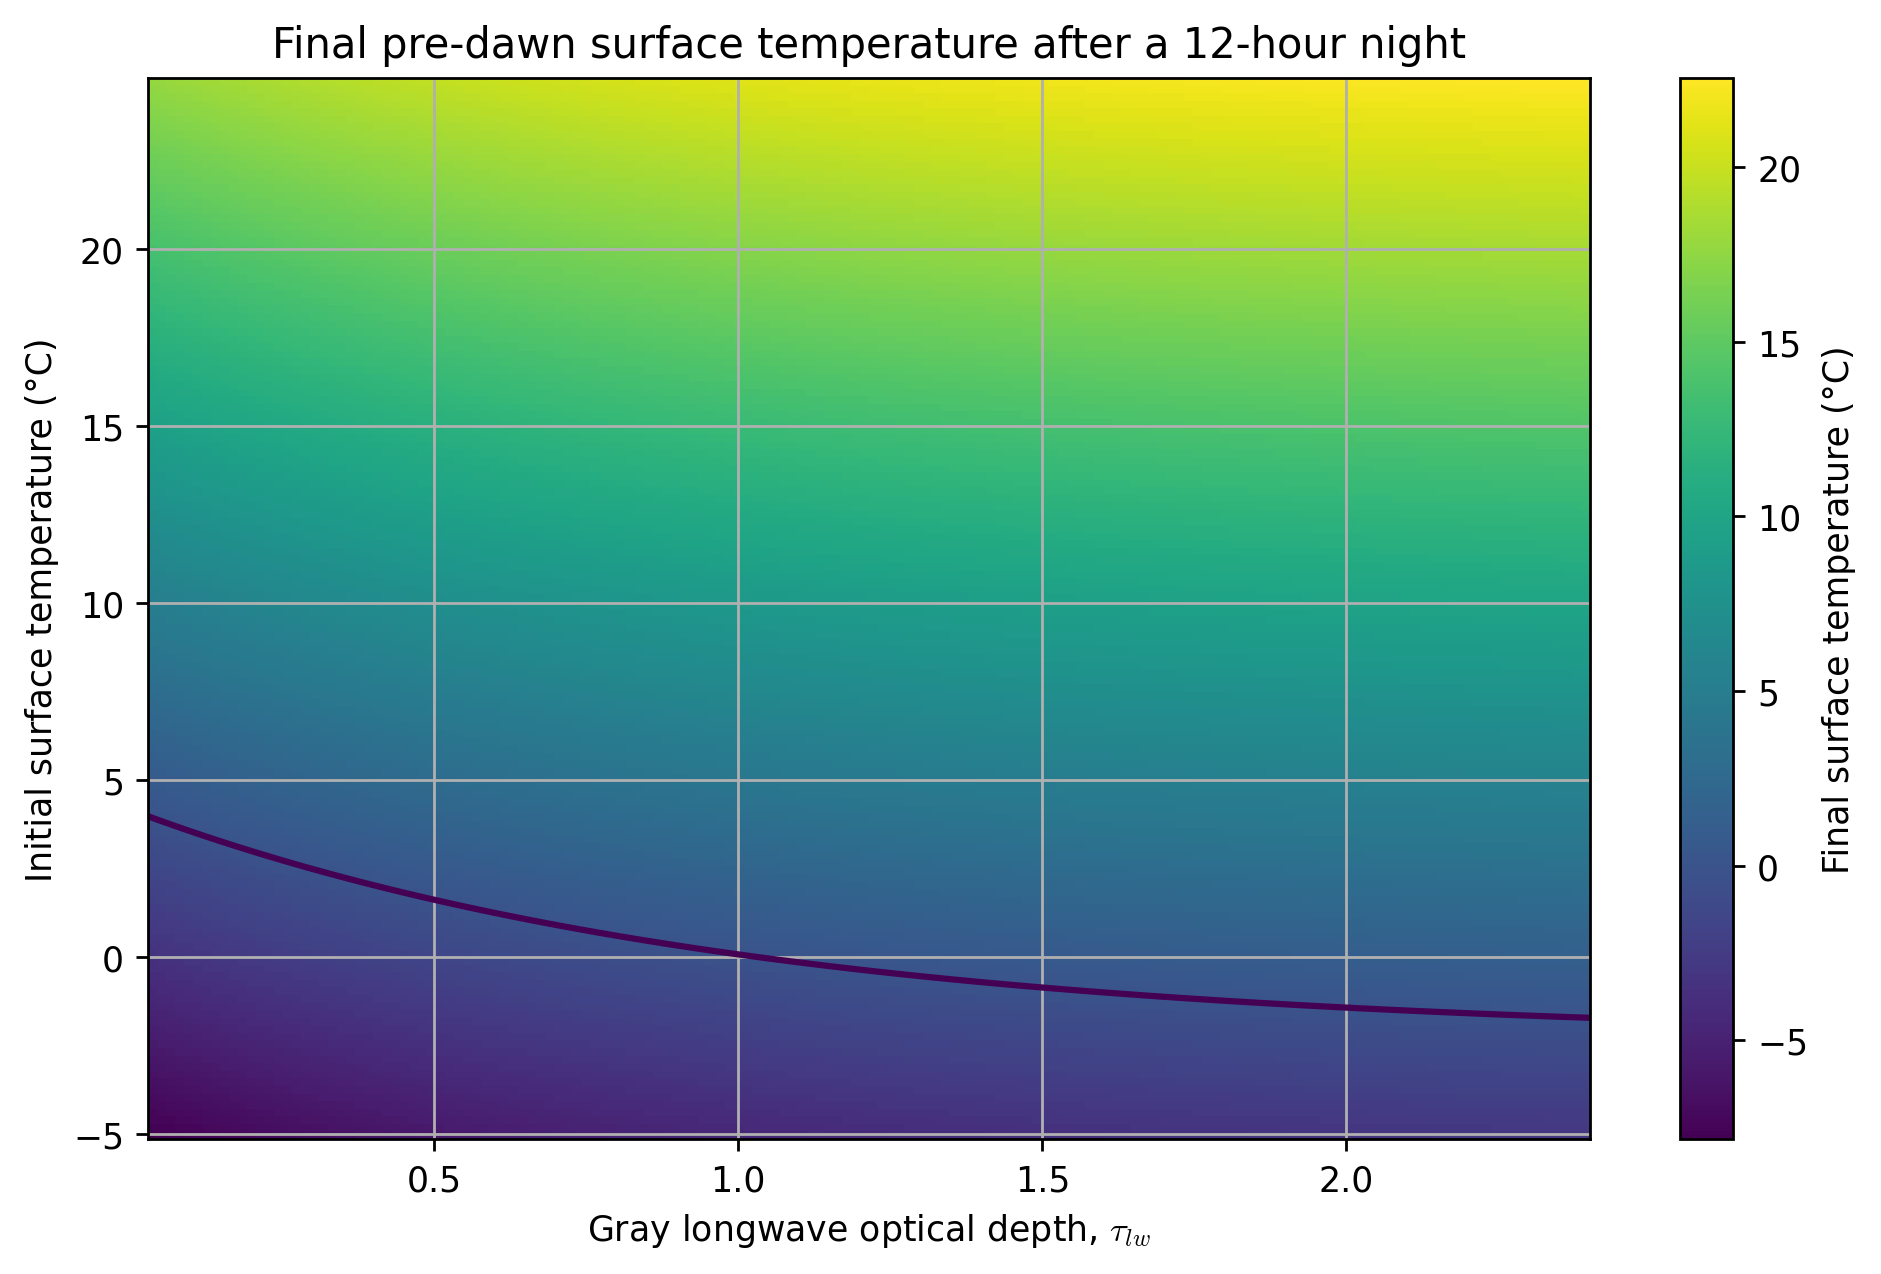

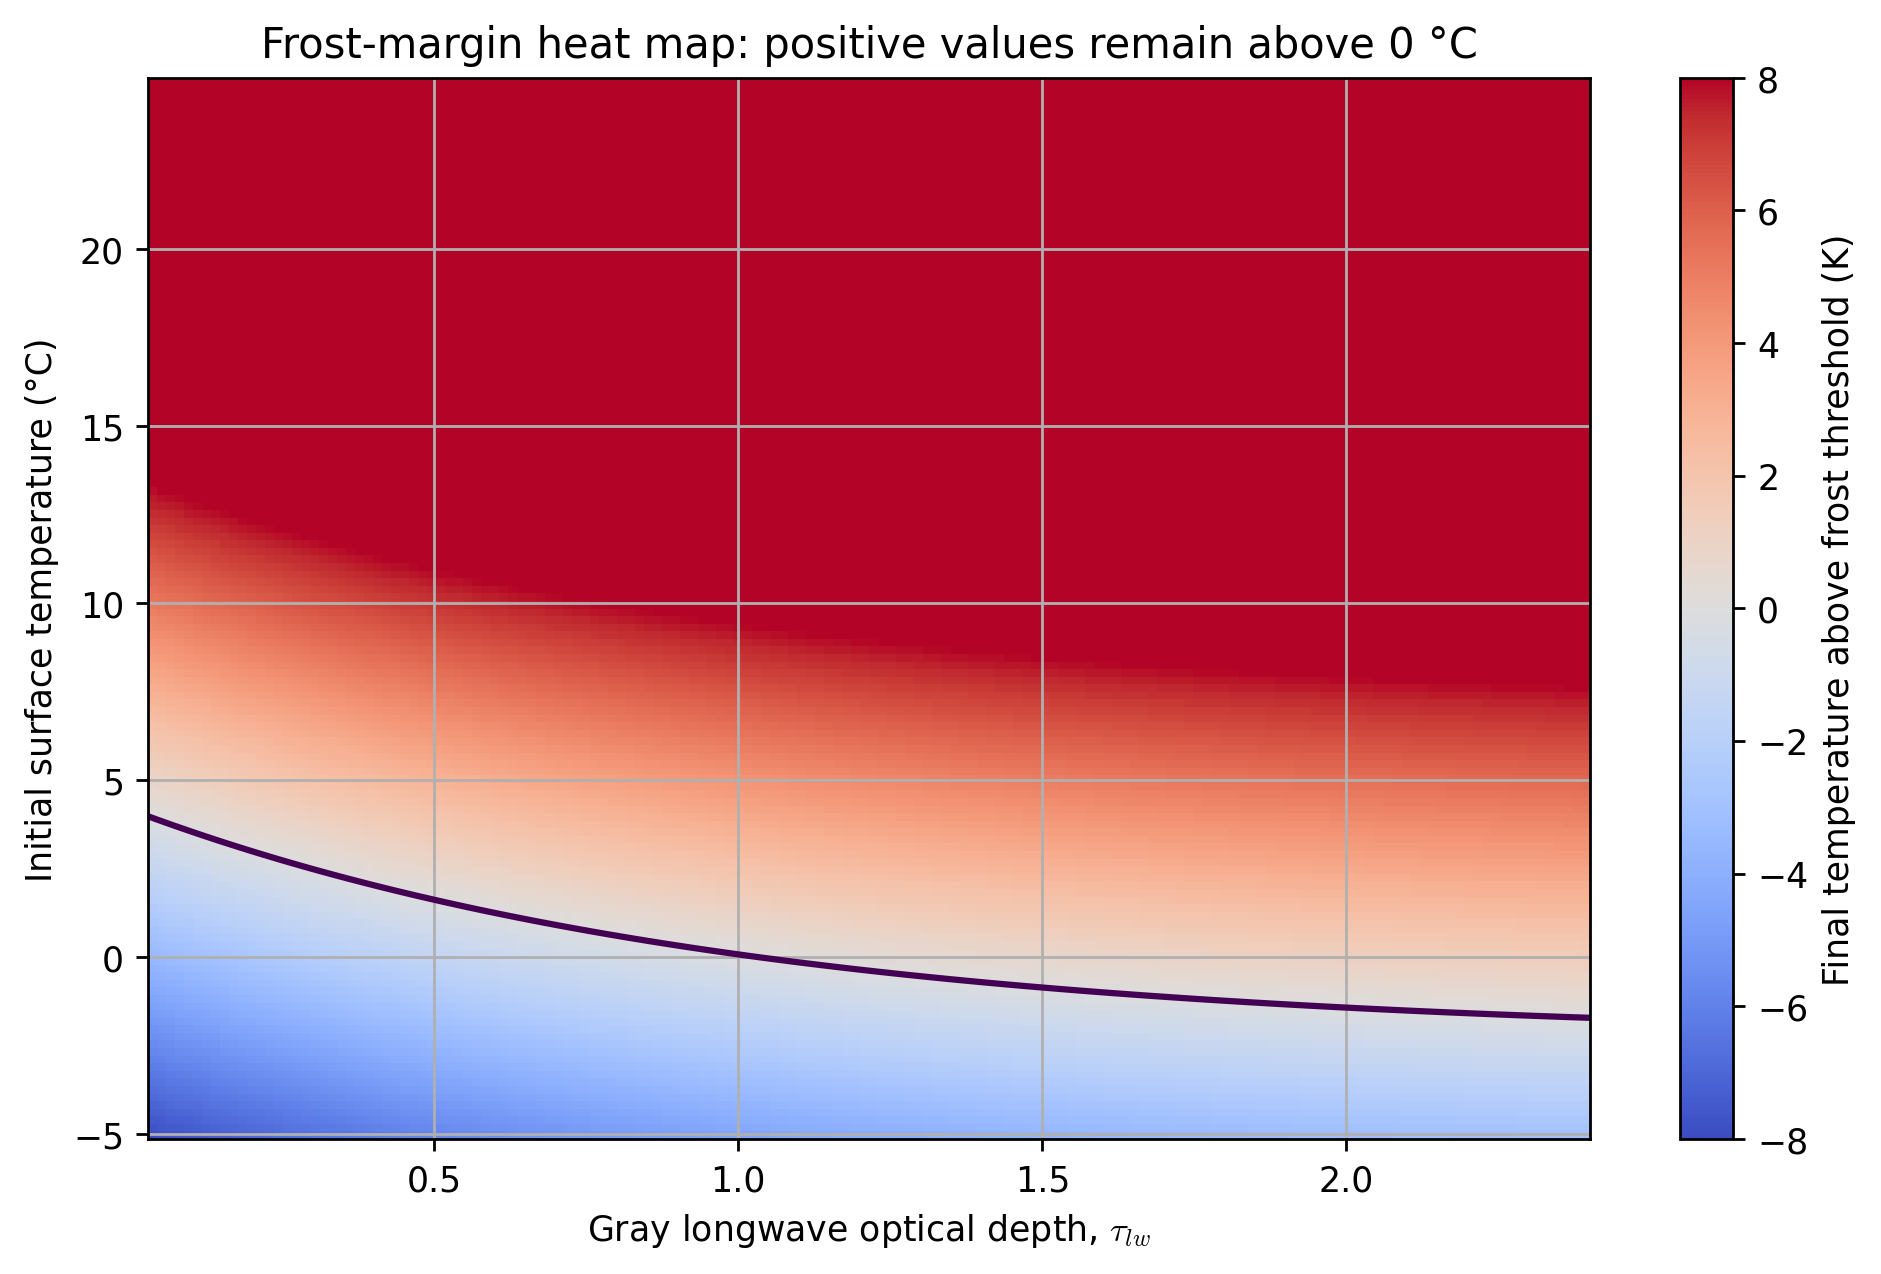

In [2]:
"""Motivational nocturnal greenhouse visualizations.

This next script visualizes the nighttime thermal-buffering role of
atmospheric longwave opacity using a compact surface-energy model. The plots
are intended for intuition building before the deeper symbolic, ODE, and Monte
Carlo models in later cells.
"""


import subprocess
import sys
from dataclasses import dataclass
from typing import Final

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_PACKAGES: Final[bool] = False
MPL_DPI: Final[int] = 250
SIGMA_SB: Final[float] = 5.670374419e-8

NIGHT_HOURS: Final[float] = 12.0
TIME_STEP_SECONDS: Final[float] = 60.0
SURFACE_HEAT_CAPACITY: Final[float] = 2.7e6  # J m^-2 K^-1
SURFACE_EMISSIVITY: Final[float] = 0.96
AIR_TEMPERATURE_K: Final[float] = 285.0
DEEP_GROUND_TEMPERATURE_K: Final[float] = 286.0
SENSIBLE_COEFFICIENT: Final[float] = 4.0  # W m^-2 K^-1
GROUND_COEFFICIENT: Final[float] = 1.2  # W m^-2 K^-1
INITIAL_SURFACE_TEMPERATURE_K: Final[float] = 291.0
FROST_THRESHOLD_K: Final[float] = 273.15

OPTICAL_DEPTH_MIN: Final[float] = 0.03
OPTICAL_DEPTH_MAX: Final[float] = 2.40
OPTICAL_DEPTH_POINTS: Final[int] = 160
INITIAL_TEMP_MIN_K: Final[float] = 268.0
INITIAL_TEMP_MAX_K: Final[float] = 298.0
INITIAL_TEMP_POINTS: Final[int] = 140

SCENARIO_DATA: Final[tuple[tuple[str, float], ...]] = (
    ("very dry clear sky", 0.20),
    ("baseline nocturnal greenhouse", 0.75),
    ("humid infrared-thick night", 1.25),
    ("cloud-enhanced longwave night", 1.95),
)

# =============================================================================
# MODEL FUNCTIONS
# =============================================================================


@dataclass(frozen=True)
class CoolingScenario:
    """Parameters for a named nighttime cooling scenario."""

    label: str
    optical_depth: float


def maybe_install_packages() -> None:
    """Install common packages if this script is run as a fresh Colab cell."""
    if INSTALL_PACKAGES:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "uv",
            ]
        )
        subprocess.check_call(
            [
                "uv",
                "pip",
                "install",
                "--system",
                "-q",
                "numpy",
                "pandas",
                "matplotlib",
            ]
        )


def configure_plots() -> None:
    """Apply notebook-friendly plot defaults."""
    mpl.rcParams["figure.dpi"] = MPL_DPI
    mpl.rcParams["savefig.dpi"] = MPL_DPI
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["mathtext.fontset"] = "cm"


def air_emissivity_from_optical_depth(optical_depth: np.ndarray | float) -> np.ndarray:
    """Convert gray longwave optical depth to effective atmospheric emissivity."""
    return 1.0 - np.exp(-np.asarray(optical_depth, dtype=float))


def downwelling_longwave(optical_depth: np.ndarray | float, air_temp_k: float) -> np.ndarray:
    """Compute downwelling atmospheric longwave radiation in W m^-2."""
    air_emissivity = air_emissivity_from_optical_depth(optical_depth)
    return air_emissivity * SIGMA_SB * air_temp_k**4


def surface_energy_rate(
    surface_temp_k: np.ndarray,
    optical_depth: np.ndarray,
    air_temp_k: float = AIR_TEMPERATURE_K,
    deep_ground_temp_k: float = DEEP_GROUND_TEMPERATURE_K,
) -> np.ndarray:
    """Return dT_s/dt for the nocturnal surface-energy balance."""
    longwave_down = downwelling_longwave(optical_depth, air_temp_k)
    longwave_up = SURFACE_EMISSIVITY * SIGMA_SB * surface_temp_k**4
    sensible = SENSIBLE_COEFFICIENT * (air_temp_k - surface_temp_k)
    ground = GROUND_COEFFICIENT * (deep_ground_temp_k - surface_temp_k)
    net_flux = longwave_down - longwave_up + sensible + ground
    return net_flux / SURFACE_HEAT_CAPACITY


def simulate_cooling(
    optical_depth: float,
    initial_surface_temp_k: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Integrate a one-state nocturnal surface model with explicit Euler steps."""
    steps = int(round(NIGHT_HOURS * 3600.0 / TIME_STEP_SECONDS)) + 1
    time_hours = np.arange(steps, dtype=float) * TIME_STEP_SECONDS / 3600.0
    surface_temp = np.empty(steps, dtype=float)
    net_flux = np.empty(steps, dtype=float)
    surface_temp[0] = initial_surface_temp_k

    for idx in range(steps - 1):
        rate = surface_energy_rate(surface_temp[idx], optical_depth)
        surface_temp[idx + 1] = surface_temp[idx] + TIME_STEP_SECONDS * rate
        longwave_down = float(downwelling_longwave(optical_depth, AIR_TEMPERATURE_K))
        longwave_up = SURFACE_EMISSIVITY * SIGMA_SB * surface_temp[idx] ** 4
        sensible = SENSIBLE_COEFFICIENT * (AIR_TEMPERATURE_K - surface_temp[idx])
        ground = GROUND_COEFFICIENT * (DEEP_GROUND_TEMPERATURE_K - surface_temp[idx])
        net_flux[idx] = longwave_down - longwave_up + sensible + ground

    net_flux[-1] = net_flux[-2]
    return time_hours, surface_temp, net_flux


def build_scenario_table() -> pd.DataFrame:
    """Summarize minimum temperature and cooling rate for key scenarios."""
    rows: list[dict[str, float | str]] = []
    for label, optical_depth in SCENARIO_DATA:
        time_hours, temp_k, net_flux = simulate_cooling(
            optical_depth=optical_depth,
            initial_surface_temp_k=INITIAL_SURFACE_TEMPERATURE_K,
        )
        cooling_rate_k_per_hour = (temp_k[-1] - temp_k[0]) / time_hours[-1]
        rows.append(
            {
                "scenario": label,
                "tau_lw": optical_depth,
                "air_emissivity": air_emissivity_from_optical_depth(optical_depth),
                "L_down_W_m2": downwelling_longwave(
                    optical_depth,
                    AIR_TEMPERATURE_K,
                ),
                "min_temp_K": np.min(temp_k),
                "min_temp_C": np.min(temp_k) - 273.15,
                "mean_net_flux_W_m2": np.mean(net_flux),
                "cooling_rate_K_per_hour": cooling_rate_k_per_hour,
            }
        )
    return pd.DataFrame(rows)


def plot_cooling_curves() -> None:
    """Plot surface temperature trajectories for named optical-depth regimes."""
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    for label, optical_depth in SCENARIO_DATA:
        time_hours, temp_k, _ = simulate_cooling(
            optical_depth=optical_depth,
            initial_surface_temp_k=INITIAL_SURFACE_TEMPERATURE_K,
        )
        ax.plot(time_hours, temp_k - 273.15, linewidth=2.0, label=label)

    ax.axhline(FROST_THRESHOLD_K - 273.15, linestyle=":", linewidth=1.5)
    ax.set_xlabel("Hours after sunset")
    ax.set_ylabel("Surface temperature (°C)")
    ax.set_title("Nocturnal cooling slows as longwave opacity increases")
    ax.legend(frameon=True, fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_longwave_balance() -> None:
    """Plot downwelling longwave radiation versus optical depth."""
    optical_depth = np.linspace(OPTICAL_DEPTH_MIN, OPTICAL_DEPTH_MAX, 300)
    l_down = downwelling_longwave(optical_depth, AIR_TEMPERATURE_K)
    emissivity = air_emissivity_from_optical_depth(optical_depth)

    fig, ax1 = plt.subplots(figsize=(8.0, 4.8))
    ax1.plot(optical_depth, l_down, linewidth=2.2)
    ax1.set_xlabel(r"Gray longwave optical depth, $\tau_{lw}$")
    ax1.set_ylabel(r"$L_{\downarrow}$ (W m$^{-2}$)")
    ax1.set_title("Downwelling longwave radiation grows with atmospheric opacity")

    ax2 = ax1.twinx()
    ax2.plot(optical_depth, emissivity, linewidth=1.8, linestyle="--")
    ax2.set_ylabel("Effective atmospheric emissivity")
    plt.tight_layout()
    plt.show()


def compute_final_temperature_grid() -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute final nighttime temperatures over initial temperature and opacity."""
    optical_depths = np.linspace(
        OPTICAL_DEPTH_MIN,
        OPTICAL_DEPTH_MAX,
        OPTICAL_DEPTH_POINTS,
    )
    initial_temps = np.linspace(
        INITIAL_TEMP_MIN_K,
        INITIAL_TEMP_MAX_K,
        INITIAL_TEMP_POINTS,
    )
    tau_grid, temp_grid = np.meshgrid(optical_depths, initial_temps)
    surface_temp = temp_grid.copy()
    steps = int(round(NIGHT_HOURS * 3600.0 / TIME_STEP_SECONDS))

    for _ in range(steps):
        surface_temp += TIME_STEP_SECONDS * surface_energy_rate(surface_temp, tau_grid)

    return optical_depths, initial_temps, surface_temp


def plot_temperature_heatmaps() -> None:
    """Render final-temperature and frost-margin heat maps."""
    optical_depths, initial_temps, final_temp = compute_final_temperature_grid()
    extent = [
        optical_depths.min(),
        optical_depths.max(),
        initial_temps.min() - 273.15,
        initial_temps.max() - 273.15,
    ]

    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    image = ax.imshow(
        final_temp - 273.15,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="viridis",
    )
    ax.contour(
        optical_depths,
        initial_temps - 273.15,
        final_temp - 273.15,
        levels=[0.0],
        linewidths=1.8,
    )
    ax.set_xlabel(r"Gray longwave optical depth, $\tau_{lw}$")
    ax.set_ylabel("Initial surface temperature (°C)")
    ax.set_title("Final pre-dawn surface temperature after a 12-hour night")
    fig.colorbar(image, ax=ax, label="Final surface temperature (°C)")
    plt.tight_layout()
    plt.show()

    frost_margin = final_temp - FROST_THRESHOLD_K
    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    image = ax.imshow(
        frost_margin,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="coolwarm",
        vmin=-8.0,
        vmax=8.0,
    )
    ax.contour(
        optical_depths,
        initial_temps - 273.15,
        frost_margin,
        levels=[0.0],
        linewidths=1.8,
    )
    ax.set_xlabel(r"Gray longwave optical depth, $\tau_{lw}$")
    ax.set_ylabel("Initial surface temperature (°C)")
    ax.set_title("Frost-margin heat map: positive values remain above 0 °C")
    fig.colorbar(image, ax=ax, label="Final temperature above frost threshold (K)")
    plt.tight_layout()
    plt.show()


def main() -> pd.DataFrame:
    """Run all motivational visualizations and return the scenario table."""
    maybe_install_packages()
    configure_plots()
    table = build_scenario_table()
    print("Scenario summary")
    print(table.to_string(index=False, float_format=lambda value: f"{value: .4f}"))
    plot_cooling_curves()
    plot_longwave_balance()
    plot_temperature_heatmaps()
    return table


if __name__ == "__main__":
    results = main()

Symbolic nocturnal cooling rate
(T_a**4*epsilon_a*sigma - T_s**4*epsilon_s*sigma + h_g*(T_g - T_s) + h_s*(T_a - T_s))/C_s

Linearized relaxation rate around T_0
(4*T_0**3*epsilon_s*sigma + h_g + h_s)/C_s

Linearized equilibrium temperature around T_0
(3*T_0**4*epsilon_s*sigma + T_a**4*epsilon_a*sigma + T_a*h_s + T_g*h_g)/(4*T_0**3*epsilon_s*sigma + h_g + h_s)


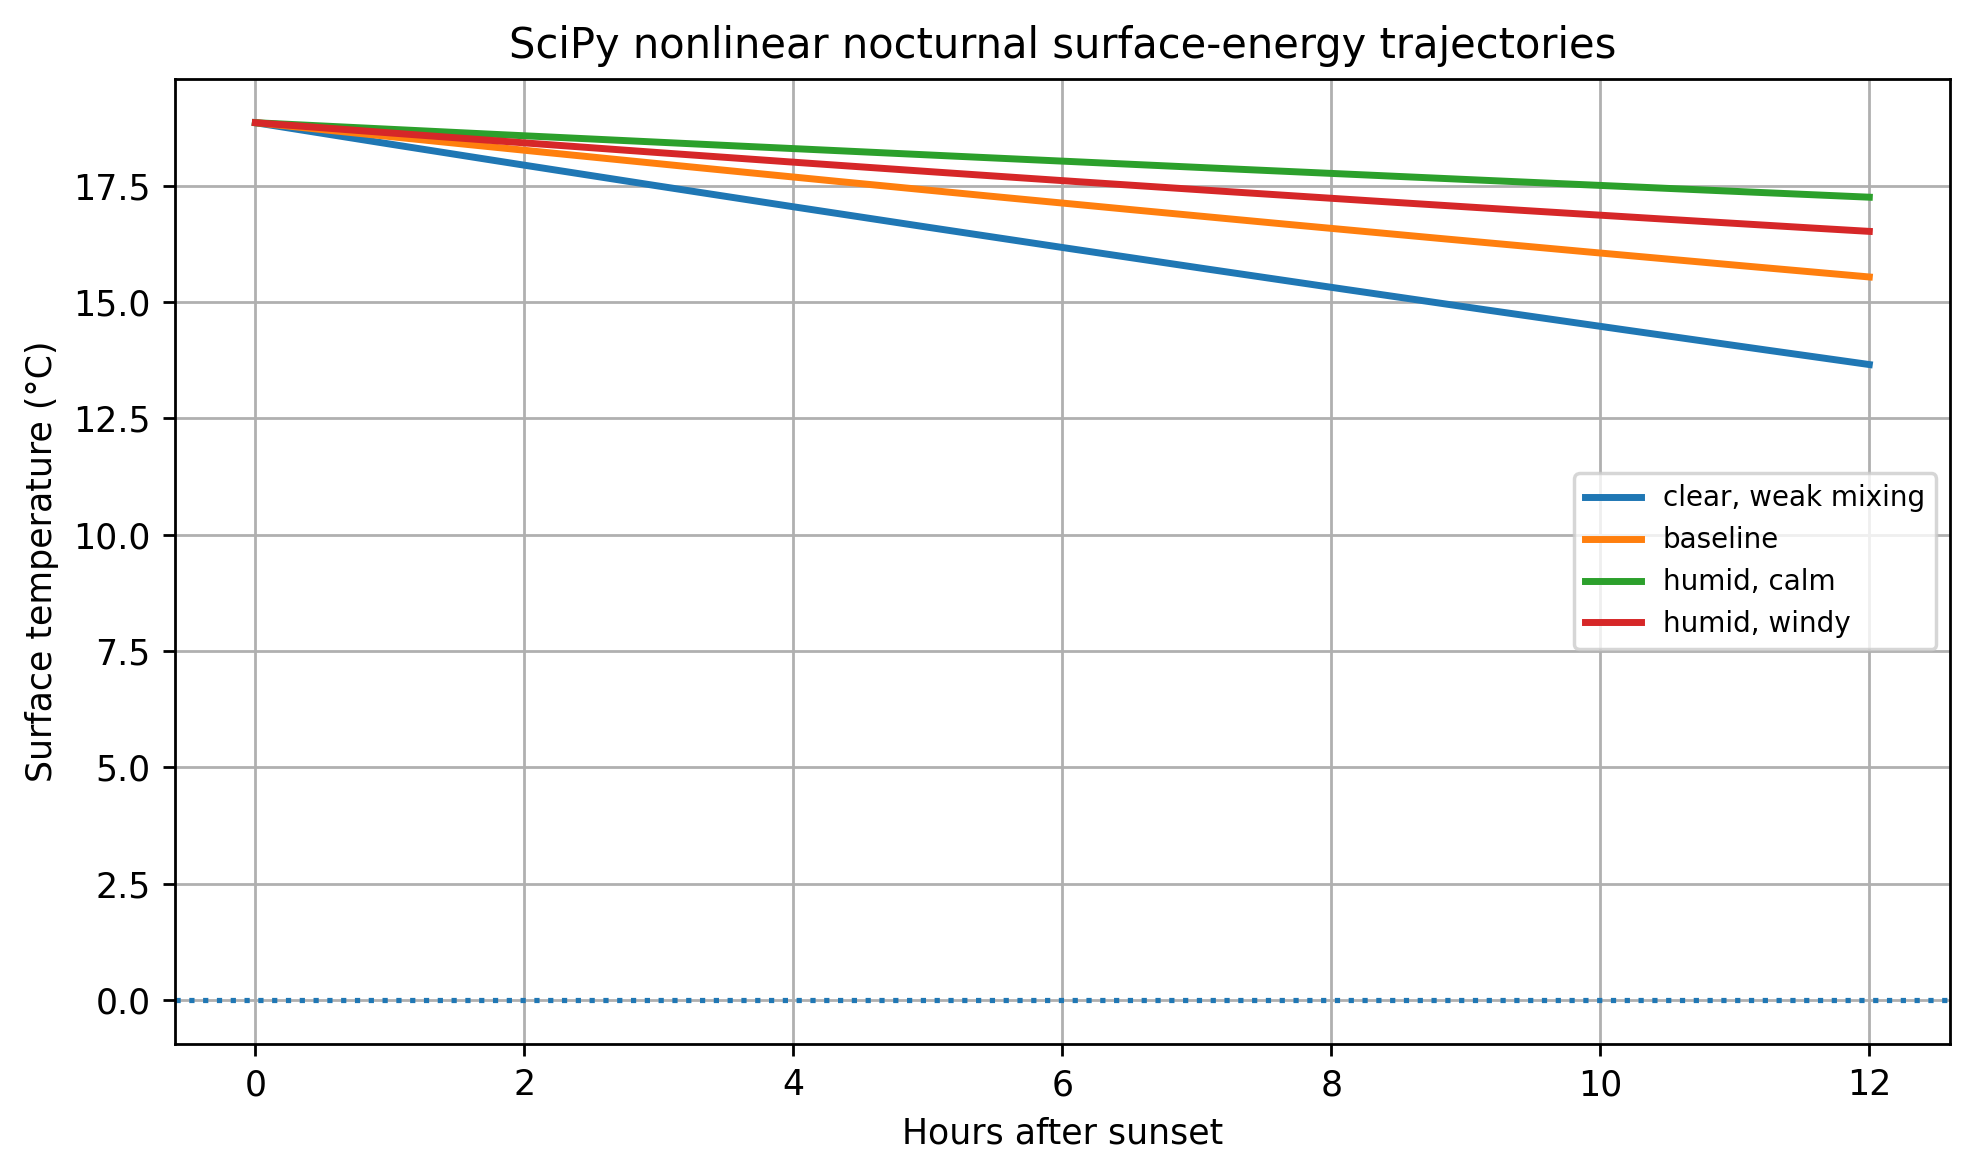


ODE case summary
              case  epsilon_a  h_s_W_m2_K  initial_C  minimum_C  final_C  initial_cooling_rate_K_per_h  final_cooling_rate_K_per_h
clear, weak mixing     0.1800      1.5000    18.8500    13.6530  13.6530                       -0.4615                     -0.4062
          baseline     0.5500      4.0000    18.8500    15.5349  15.5349                       -0.3002                     -0.2537
       humid, calm     0.8200      1.5000    18.8500    17.2490  17.2490                       -0.1422                     -0.1250
      humid, windy     0.8200     10.0000    18.8500    16.5145  16.5145                       -0.2216                     -0.1700


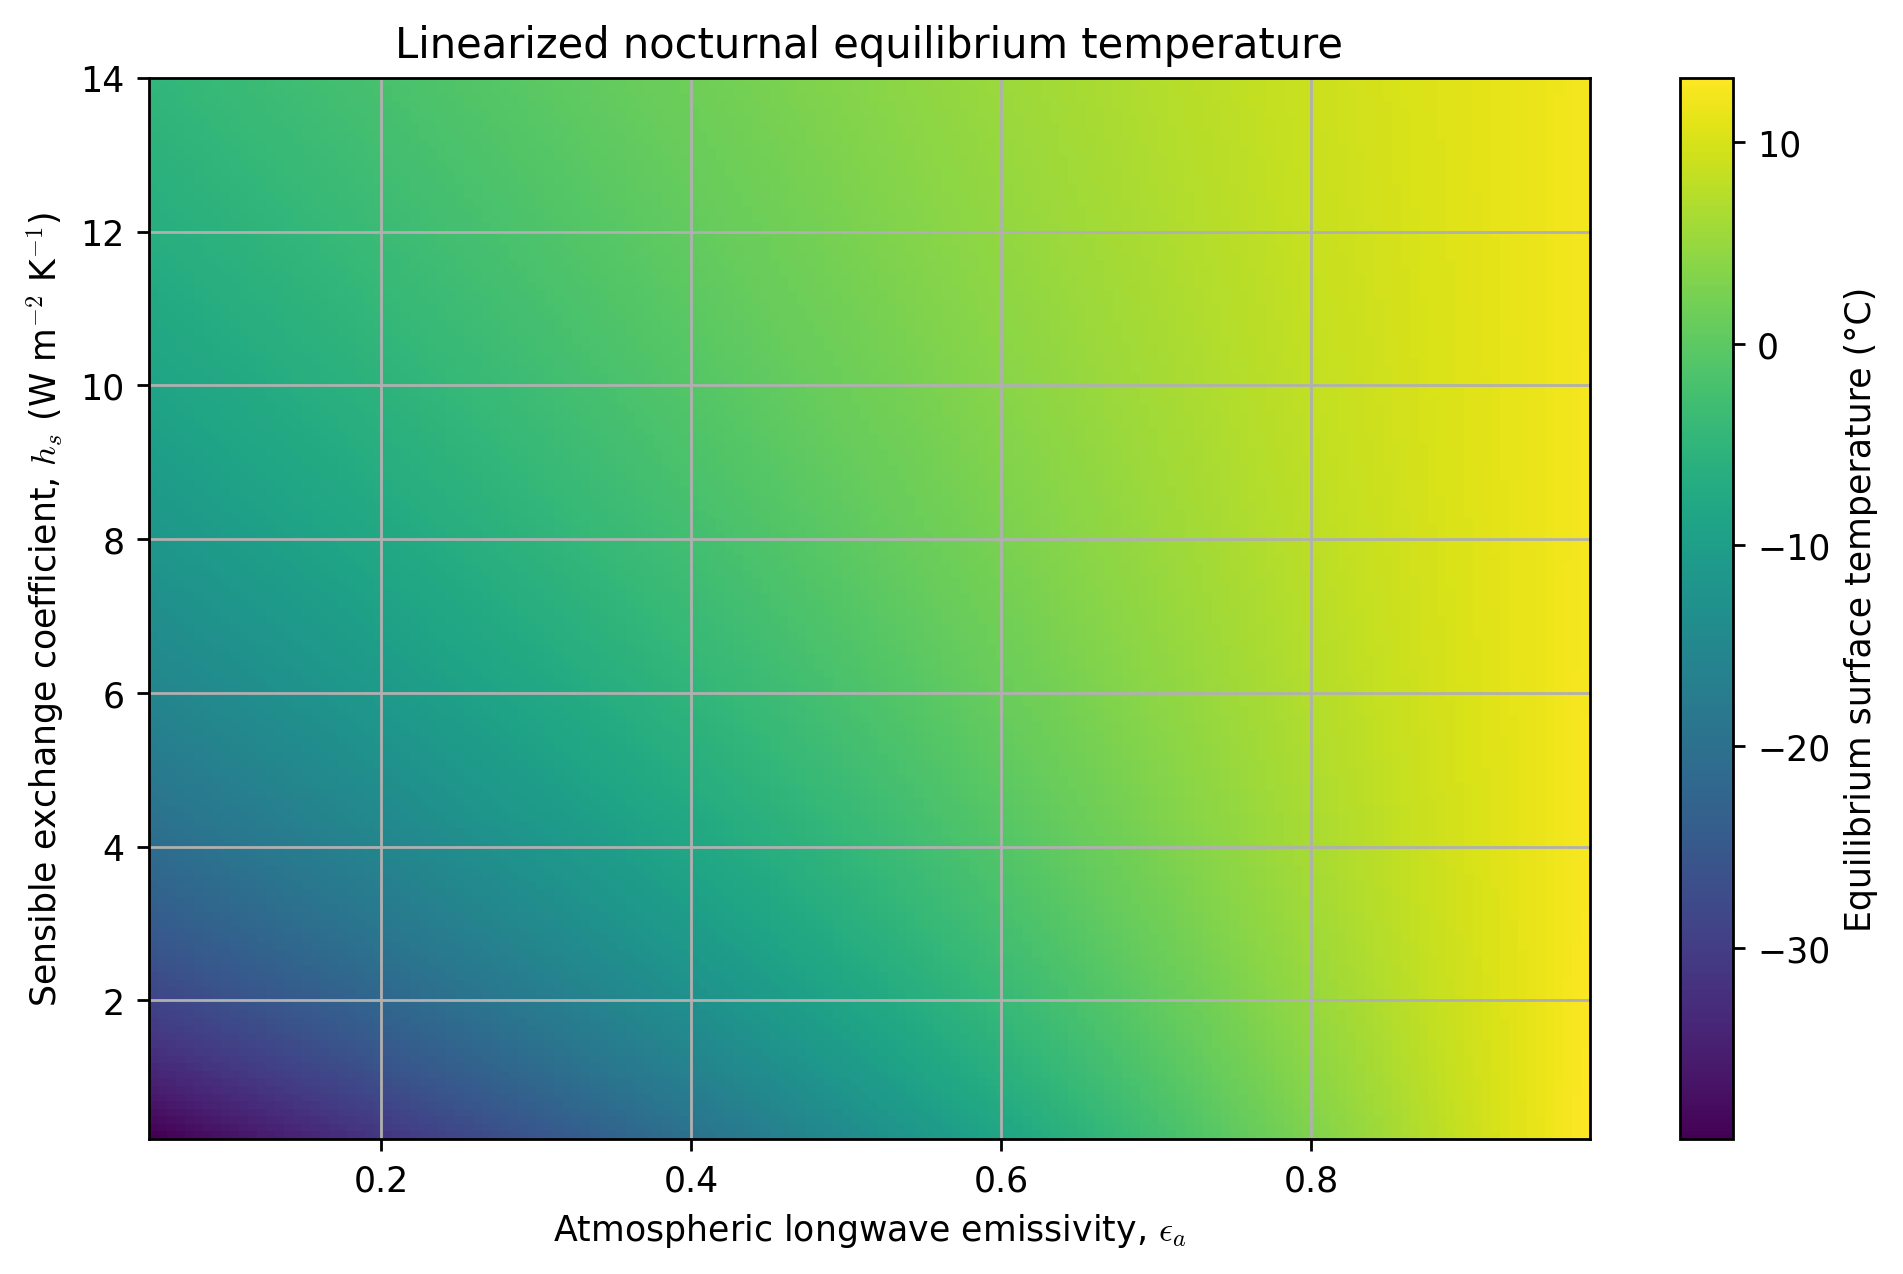

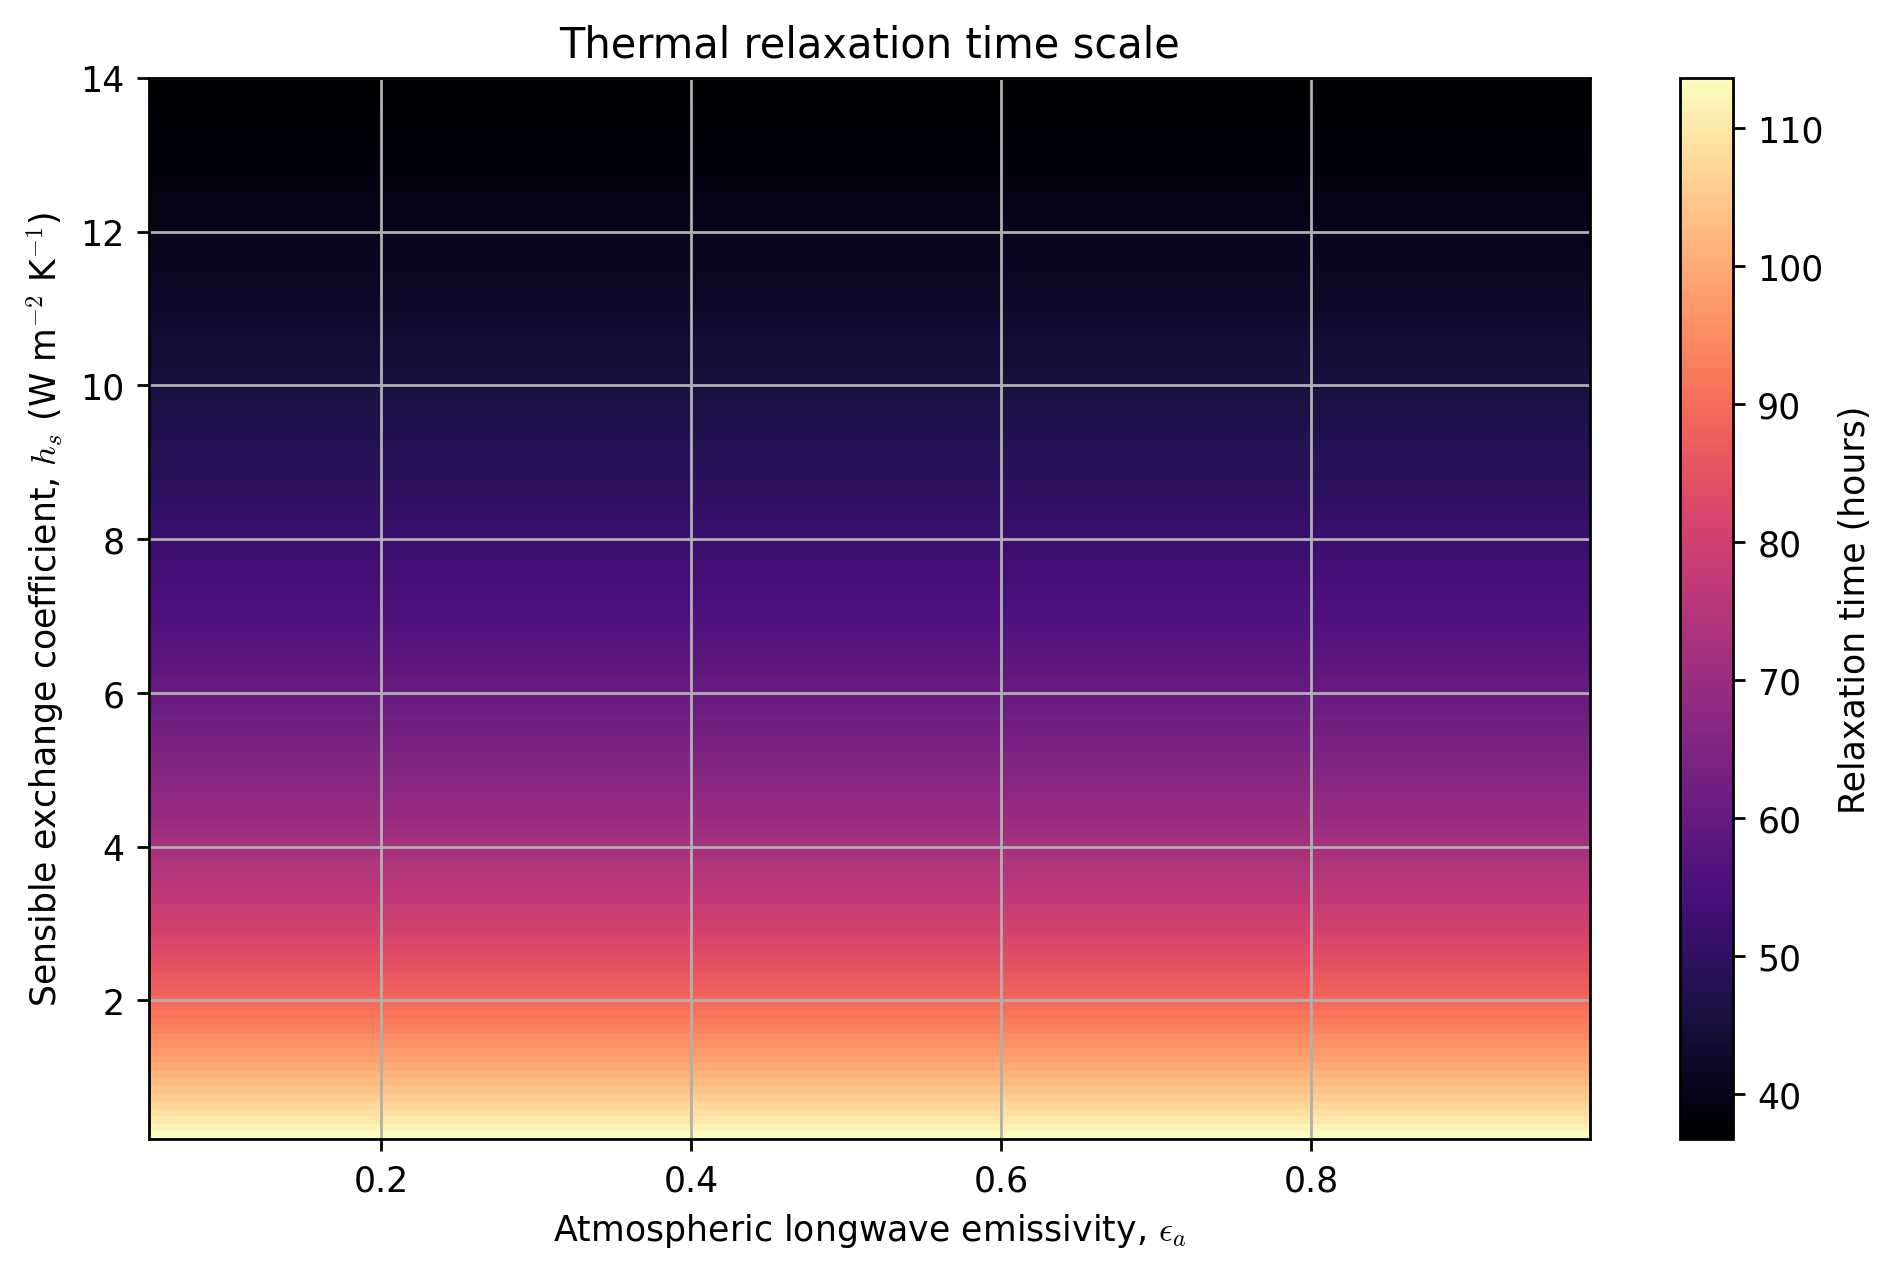

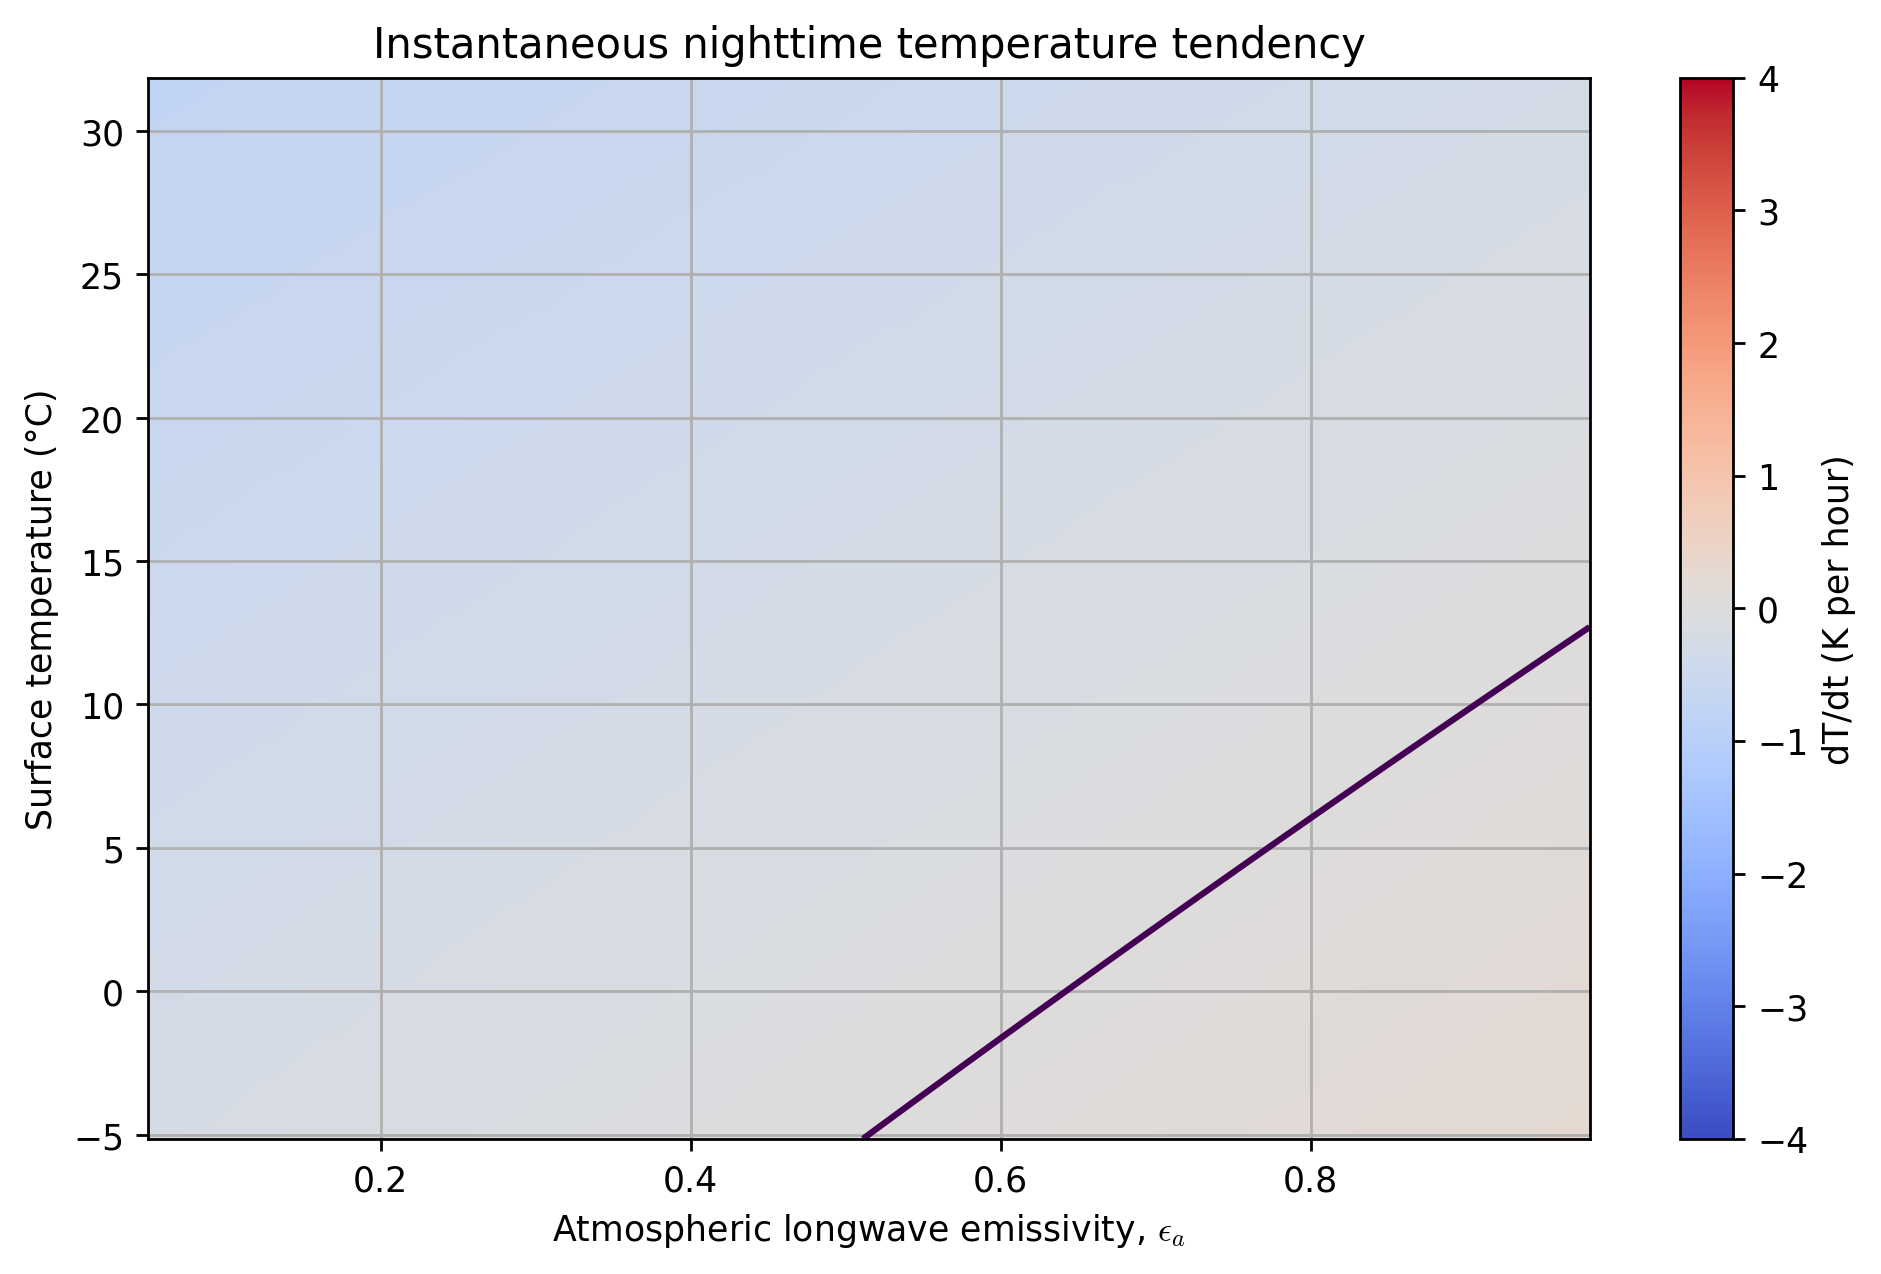

In [3]:
"""Symbolic and SciPy deep dive for nocturnal greenhouse buffering.

This cell derives a linearized nocturnal surface-energy model with SymPy,
converts symbolic expressions into numerical functions, solves ODE trajectories
with SciPy, and renders heat maps for cooling rate, equilibrium temperature,
and thermal relaxation time.
"""


import subprocess
import sys
from dataclasses import dataclass
from typing import Callable, Final

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sym
from scipy.integrate import solve_ivp

# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_PACKAGES: Final[bool] = False
MPL_DPI: Final[int] = 250
SIGMA_SB: Final[float] = 5.670374419e-8

SURFACE_HEAT_CAPACITY: Final[float] = 2.7e6
SURFACE_EMISSIVITY: Final[float] = 0.96
REFERENCE_SURFACE_TEMP_K: Final[float] = 288.0
AIR_TEMP_K: Final[float] = 285.0
DEEP_GROUND_TEMP_K: Final[float] = 286.0
NIGHT_HOURS: Final[float] = 12.0
EVALUATION_POINTS: Final[int] = 361

INITIAL_SURFACE_TEMP_K: Final[float] = 292.0
FROST_THRESHOLD_K: Final[float] = 273.15

EMISSIVITY_POINTS: Final[int] = 160
MIXING_POINTS: Final[int] = 140
SURFACE_TEMP_POINTS: Final[int] = 140
EMISSIVITY_RANGE: Final[tuple[float, float]] = (0.05, 0.98)
MIXING_RANGE_W_M2_K: Final[tuple[float, float]] = (0.2, 14.0)
SURFACE_TEMP_RANGE_K: Final[tuple[float, float]] = (268.0, 305.0)
GROUND_COEFFICIENT: Final[float] = 1.2

# =============================================================================
# SYMBOLIC MODEL
# =============================================================================


@dataclass(frozen=True)
class OdeCase:
    """Container for a nocturnal ODE scenario."""

    label: str
    atmospheric_emissivity: float
    sensible_coefficient: float
    initial_surface_temp_k: float


def maybe_install_packages() -> None:
    """Install dependencies if this file is pasted as a fresh Colab cell."""
    if INSTALL_PACKAGES:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "uv"]
        )
        subprocess.check_call(
            [
                "uv",
                "pip",
                "install",
                "--system",
                "-q",
                "numpy",
                "pandas",
                "matplotlib",
                "scipy",
                "sympy",
            ]
        )


def configure_plots() -> None:
    """Configure high-DPI plots for Colab rendering."""
    mpl.rcParams["figure.dpi"] = MPL_DPI
    mpl.rcParams["savefig.dpi"] = MPL_DPI
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["mathtext.fontset"] = "cm"


def build_symbolic_model() -> dict[str, sym.Expr]:
    """Build symbolic cooling-rate and linearized solution expressions."""
    ts, ta, tg, eps_a, eps_s, sigma, hs, hg, cs, t0 = sym.symbols(
        "T_s T_a T_g epsilon_a epsilon_s sigma h_s h_g C_s T_0",
        positive=True,
        real=True,
    )
    time = sym.symbols("t", nonnegative=True, real=True)

    net_flux = eps_a * sigma * ta**4 - eps_s * sigma * ts**4
    net_flux += hs * (ta - ts) + hg * (tg - ts)
    rate = net_flux / cs

    derivative_at_t0 = sym.diff(rate, ts).subs(ts, t0)
    lambda_linear = -derivative_at_t0
    forcing_at_t0 = rate.subs(ts, t0) + lambda_linear * t0
    equilibrium_linear = sym.simplify(forcing_at_t0 / lambda_linear)
    solution_linear = sym.simplify(
        equilibrium_linear + (ts - equilibrium_linear) * sym.exp(-lambda_linear * time)
    )

    return {
        "rate": sym.simplify(rate),
        "lambda_linear": sym.simplify(lambda_linear),
        "equilibrium_linear": sym.simplify(equilibrium_linear),
        "solution_linear": solution_linear,
    }


def make_numeric_functions() -> tuple[Callable[..., np.ndarray], Callable[..., np.ndarray], Callable[..., np.ndarray]]:
    """Create NumPy-callable functions from SymPy expressions."""
    model = build_symbolic_model()
    ts, ta, tg, eps_a, eps_s, sigma, hs, hg, cs, t0 = sym.symbols(
        "T_s T_a T_g epsilon_a epsilon_s sigma h_s h_g C_s T_0",
        positive=True,
        real=True,
    )
    rate_func = sym.lambdify(
        (ts, ta, tg, eps_a, eps_s, sigma, hs, hg, cs),
        model["rate"],
        "numpy",
    )
    lambda_func = sym.lambdify(
        (t0, eps_s, sigma, hs, hg, cs),
        model["lambda_linear"],
        "numpy",
    )
    equilibrium_func = sym.lambdify(
        (ta, tg, eps_a, eps_s, sigma, hs, hg, cs, t0),
        model["equilibrium_linear"],
        "numpy",
    )
    return rate_func, lambda_func, equilibrium_func


def print_symbolic_expressions() -> None:
    """Print the derived symbolic expressions in compact text form."""
    model = build_symbolic_model()
    print("Symbolic nocturnal cooling rate")
    print(sym.sstr(model["rate"]))
    print("\nLinearized relaxation rate around T_0")
    print(sym.sstr(model["lambda_linear"]))
    print("\nLinearized equilibrium temperature around T_0")
    print(sym.sstr(model["equilibrium_linear"]))


def solve_temperature_case(case: OdeCase) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Solve the nonlinear nocturnal ODE for one named case."""
    rate_func, _, _ = make_numeric_functions()

    def rhs(_time_seconds: float, state: np.ndarray) -> np.ndarray:
        return np.asarray(
            [
                rate_func(
                    state[0],
                    AIR_TEMP_K,
                    DEEP_GROUND_TEMP_K,
                    case.atmospheric_emissivity,
                    SURFACE_EMISSIVITY,
                    SIGMA_SB,
                    case.sensible_coefficient,
                    GROUND_COEFFICIENT,
                    SURFACE_HEAT_CAPACITY,
                )
            ],
            dtype=float,
        )

    t_eval = np.linspace(0.0, NIGHT_HOURS * 3600.0, EVALUATION_POINTS)
    solution = solve_ivp(
        rhs,
        (0.0, NIGHT_HOURS * 3600.0),
        y0=np.asarray([case.initial_surface_temp_k], dtype=float),
        t_eval=t_eval,
        method="RK45",
        rtol=1e-7,
        atol=1e-8,
    )
    if solution.success is False:
        raise RuntimeError(solution.message)

    temps = solution.y[0]
    rates = np.asarray([rhs(time, np.asarray([temp]))[0] for time, temp in zip(t_eval, temps)])
    return t_eval / 3600.0, temps, rates * 3600.0


def run_ode_cases() -> pd.DataFrame:
    """Run several ODE cases and plot their trajectories."""
    cases = (
        OdeCase("clear, weak mixing", 0.18, 1.5, INITIAL_SURFACE_TEMP_K),
        OdeCase("baseline", 0.55, 4.0, INITIAL_SURFACE_TEMP_K),
        OdeCase("humid, calm", 0.82, 1.5, INITIAL_SURFACE_TEMP_K),
        OdeCase("humid, windy", 0.82, 10.0, INITIAL_SURFACE_TEMP_K),
    )
    rows: list[dict[str, float | str]] = []

    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    for case in cases:
        hours, temps, cooling_rate = solve_temperature_case(case)
        ax.plot(hours, temps - 273.15, linewidth=2.0, label=case.label)
        rows.append(
            {
                "case": case.label,
                "epsilon_a": case.atmospheric_emissivity,
                "h_s_W_m2_K": case.sensible_coefficient,
                "initial_C": case.initial_surface_temp_k - 273.15,
                "minimum_C": temps.min() - 273.15,
                "final_C": temps[-1] - 273.15,
                "initial_cooling_rate_K_per_h": cooling_rate[0],
                "final_cooling_rate_K_per_h": cooling_rate[-1],
            }
        )

    ax.axhline(FROST_THRESHOLD_K - 273.15, linestyle=":", linewidth=1.5)
    ax.set_xlabel("Hours after sunset")
    ax.set_ylabel("Surface temperature (°C)")
    ax.set_title("SciPy nonlinear nocturnal surface-energy trajectories")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(rows)
    print("\nODE case summary")
    print(table.to_string(index=False, float_format=lambda value: f"{value: .4f}"))
    return table


def plot_symbolic_heatmaps() -> None:
    """Plot cooling-rate, equilibrium, and time-constant heat maps."""
    rate_func, lambda_func, equilibrium_func = make_numeric_functions()
    emissivity = np.linspace(*EMISSIVITY_RANGE, EMISSIVITY_POINTS)
    mixing = np.linspace(*MIXING_RANGE_W_M2_K, MIXING_POINTS)
    surface_temp = np.linspace(*SURFACE_TEMP_RANGE_K, SURFACE_TEMP_POINTS)

    eps_grid, mix_grid = np.meshgrid(emissivity, mixing)
    lambda_grid = lambda_func(
        REFERENCE_SURFACE_TEMP_K,
        SURFACE_EMISSIVITY,
        SIGMA_SB,
        mix_grid,
        GROUND_COEFFICIENT,
        SURFACE_HEAT_CAPACITY,
    )
    tau_hours = 1.0 / lambda_grid / 3600.0
    equilibrium_grid = equilibrium_func(
        AIR_TEMP_K,
        DEEP_GROUND_TEMP_K,
        eps_grid,
        SURFACE_EMISSIVITY,
        SIGMA_SB,
        mix_grid,
        GROUND_COEFFICIENT,
        SURFACE_HEAT_CAPACITY,
        REFERENCE_SURFACE_TEMP_K,
    )

    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    image = ax.imshow(
        equilibrium_grid - 273.15,
        origin="lower",
        aspect="auto",
        extent=[
            emissivity.min(),
            emissivity.max(),
            mixing.min(),
            mixing.max(),
        ],
        cmap="viridis",
    )
    ax.set_xlabel(r"Atmospheric longwave emissivity, $\epsilon_a$")
    ax.set_ylabel(r"Sensible exchange coefficient, $h_s$ (W m$^{-2}$ K$^{-1}$)")
    ax.set_title("Linearized nocturnal equilibrium temperature")
    fig.colorbar(image, ax=ax, label="Equilibrium surface temperature (°C)")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    image = ax.imshow(
        tau_hours,
        origin="lower",
        aspect="auto",
        extent=[
            emissivity.min(),
            emissivity.max(),
            mixing.min(),
            mixing.max(),
        ],
        cmap="magma",
    )
    ax.set_xlabel(r"Atmospheric longwave emissivity, $\epsilon_a$")
    ax.set_ylabel(r"Sensible exchange coefficient, $h_s$ (W m$^{-2}$ K$^{-1}$)")
    ax.set_title("Thermal relaxation time scale")
    fig.colorbar(image, ax=ax, label="Relaxation time (hours)")
    plt.tight_layout()
    plt.show()

    eps_grid_2, temp_grid = np.meshgrid(emissivity, surface_temp)
    rate_grid = rate_func(
        temp_grid,
        AIR_TEMP_K,
        DEEP_GROUND_TEMP_K,
        eps_grid_2,
        SURFACE_EMISSIVITY,
        SIGMA_SB,
        4.0,
        GROUND_COEFFICIENT,
        SURFACE_HEAT_CAPACITY,
    )

    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    image = ax.imshow(
        rate_grid * 3600.0,
        origin="lower",
        aspect="auto",
        extent=[
            emissivity.min(),
            emissivity.max(),
            surface_temp.min() - 273.15,
            surface_temp.max() - 273.15,
        ],
        cmap="coolwarm",
        vmin=-4.0,
        vmax=4.0,
    )
    ax.contour(
        emissivity,
        surface_temp - 273.15,
        rate_grid * 3600.0,
        levels=[0.0],
        linewidths=1.8,
    )
    ax.set_xlabel(r"Atmospheric longwave emissivity, $\epsilon_a$")
    ax.set_ylabel("Surface temperature (°C)")
    ax.set_title("Instantaneous nighttime temperature tendency")
    fig.colorbar(image, ax=ax, label="dT/dt (K per hour)")
    plt.tight_layout()
    plt.show()


def main() -> pd.DataFrame:
    """Run symbolic derivation, SciPy trajectories, and heat maps."""
    maybe_install_packages()
    configure_plots()
    print_symbolic_expressions()
    ode_table = run_ode_cases()
    plot_symbolic_heatmaps()
    return ode_table


if __name__ == "__main__":
    results = main()

Backend: CuPy GPU; packets per grid point: 10000
Photon-packet fate summary
 tau_lw  surface_absorptivity  return_fraction  escape_fraction  trapped_fraction  reflected_fraction  mean_interactions  packet_count
 0.1500                0.9600           0.0652           0.9348            0.0000              0.0024             0.1517    10000.0000
 0.6000                0.9600           0.2230           0.7770            0.0000              0.0101             0.6097    10000.0000
 1.5000                0.9600           0.4191           0.5809            0.0000              0.0155             1.5364    10000.0000
 3.0000                0.9600           0.5937           0.4063            0.0000              0.0252             3.0998    10000.0000
 5.0000                0.9600           0.7062           0.2938            0.0000              0.0293             5.1185    10000.0000


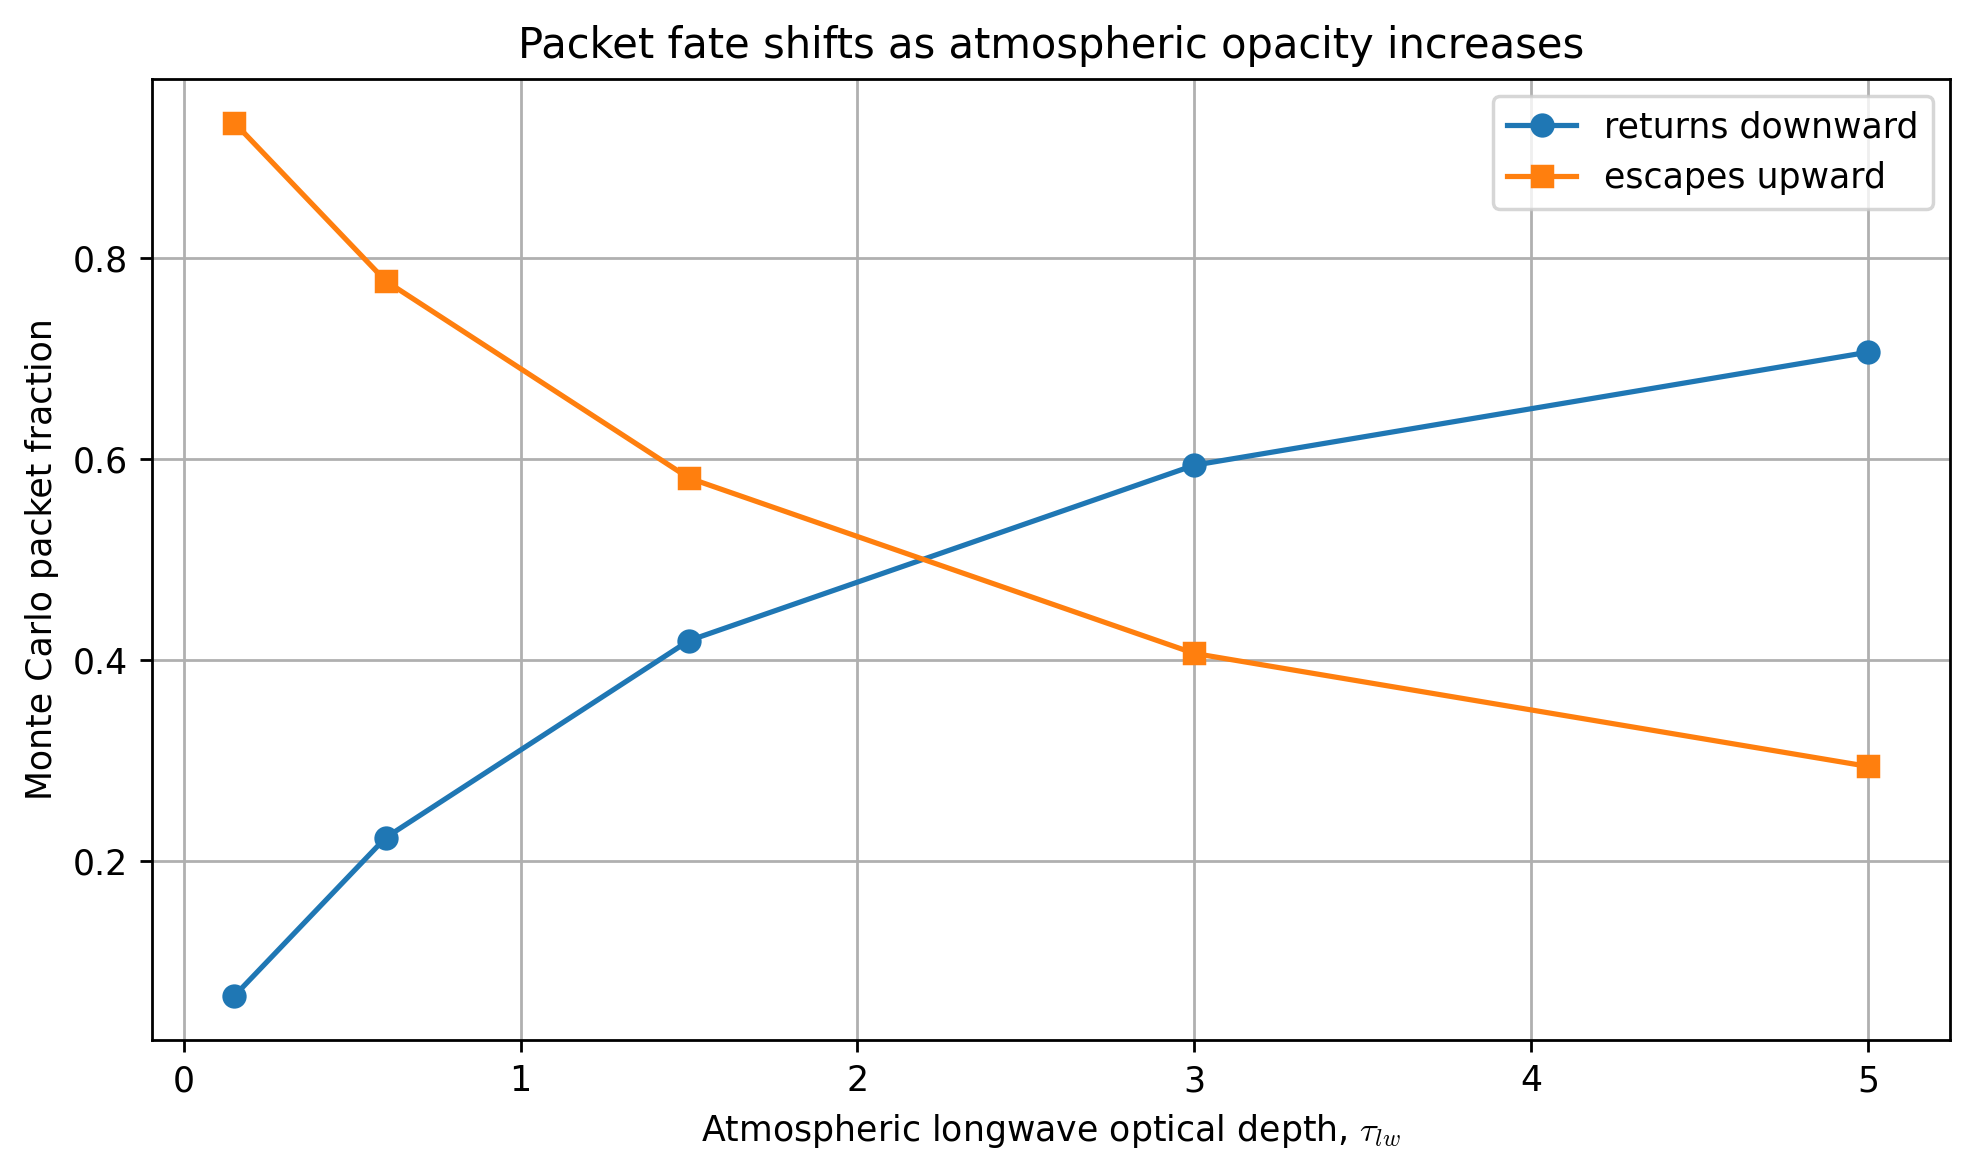

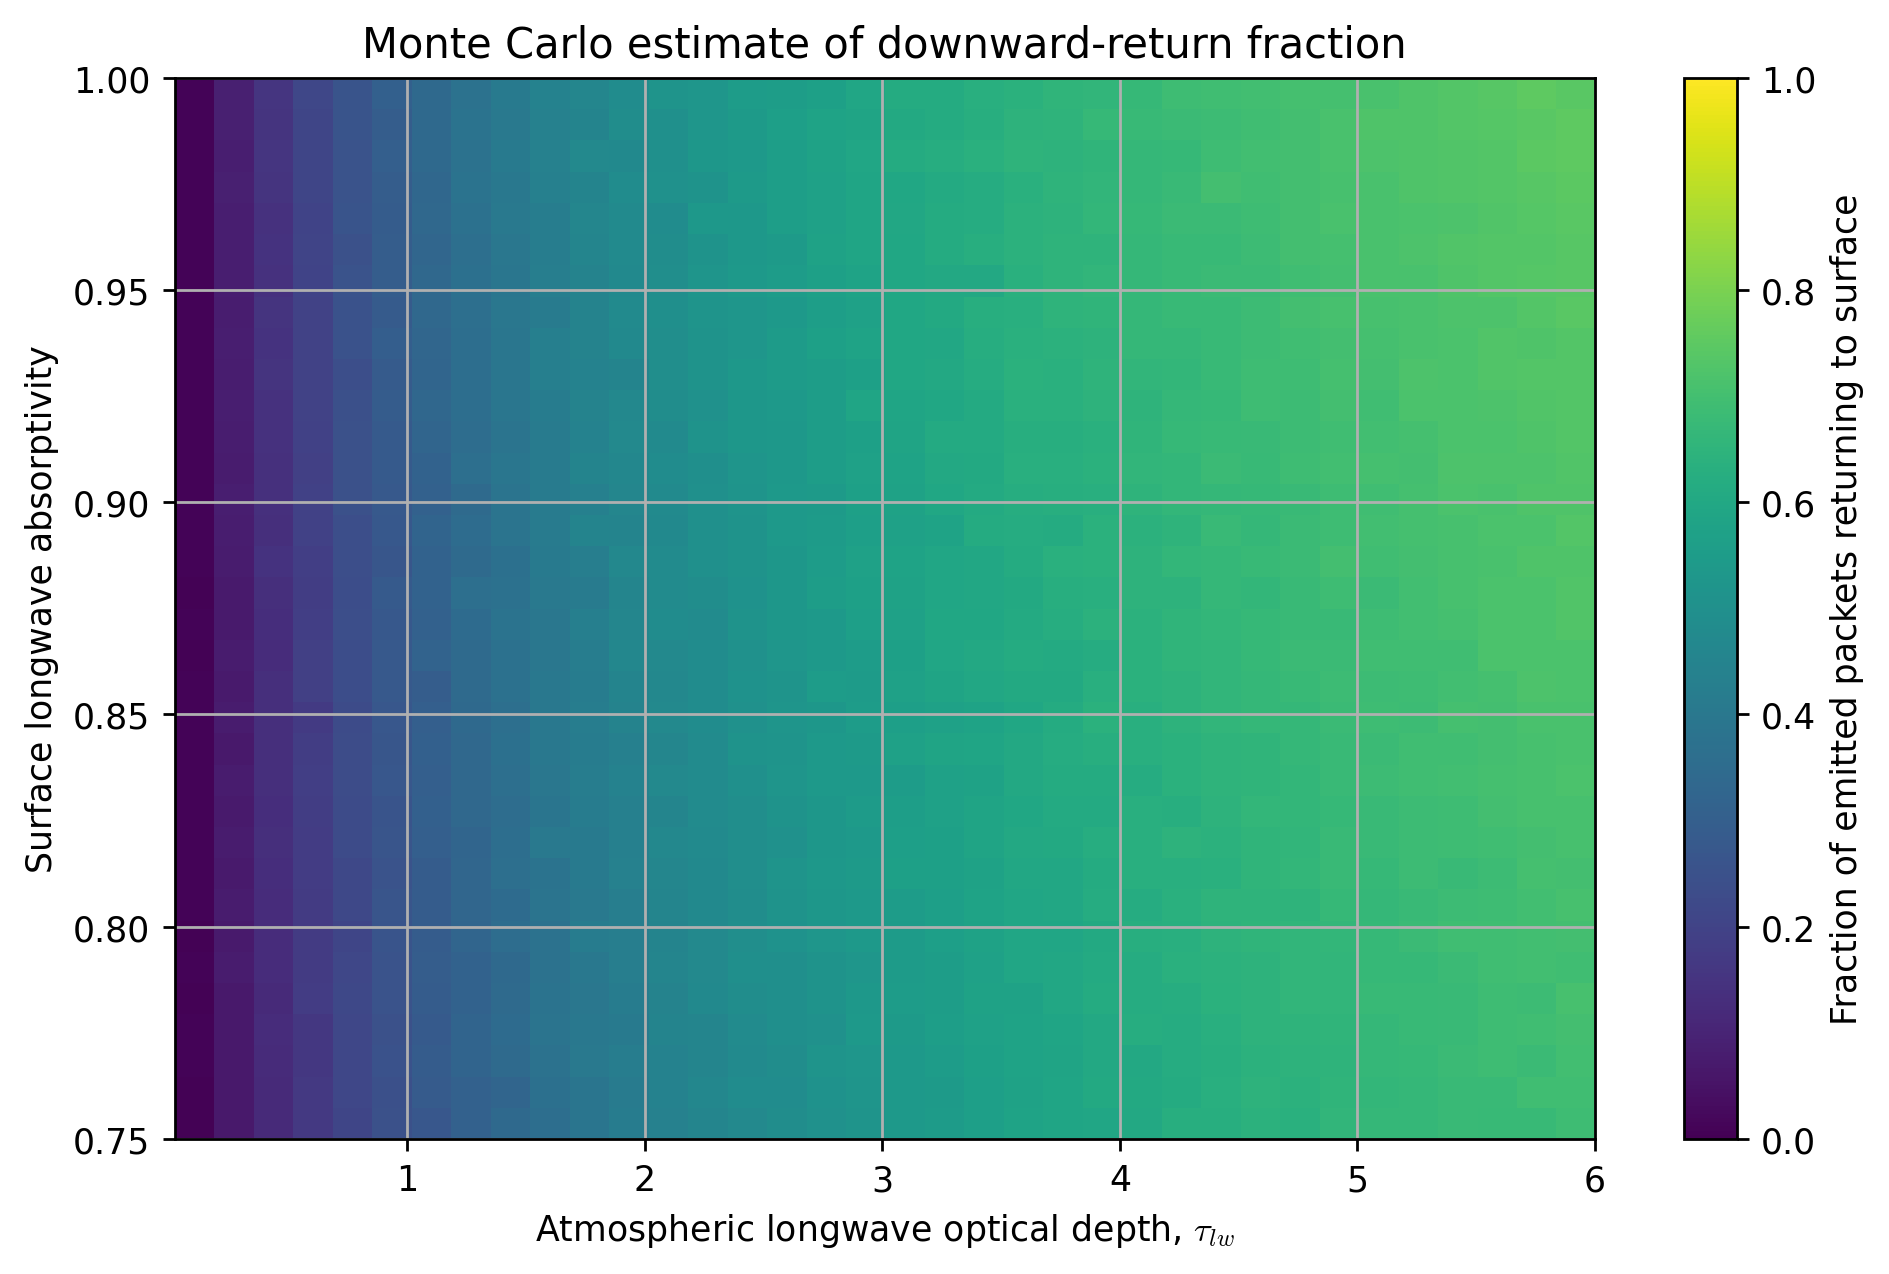

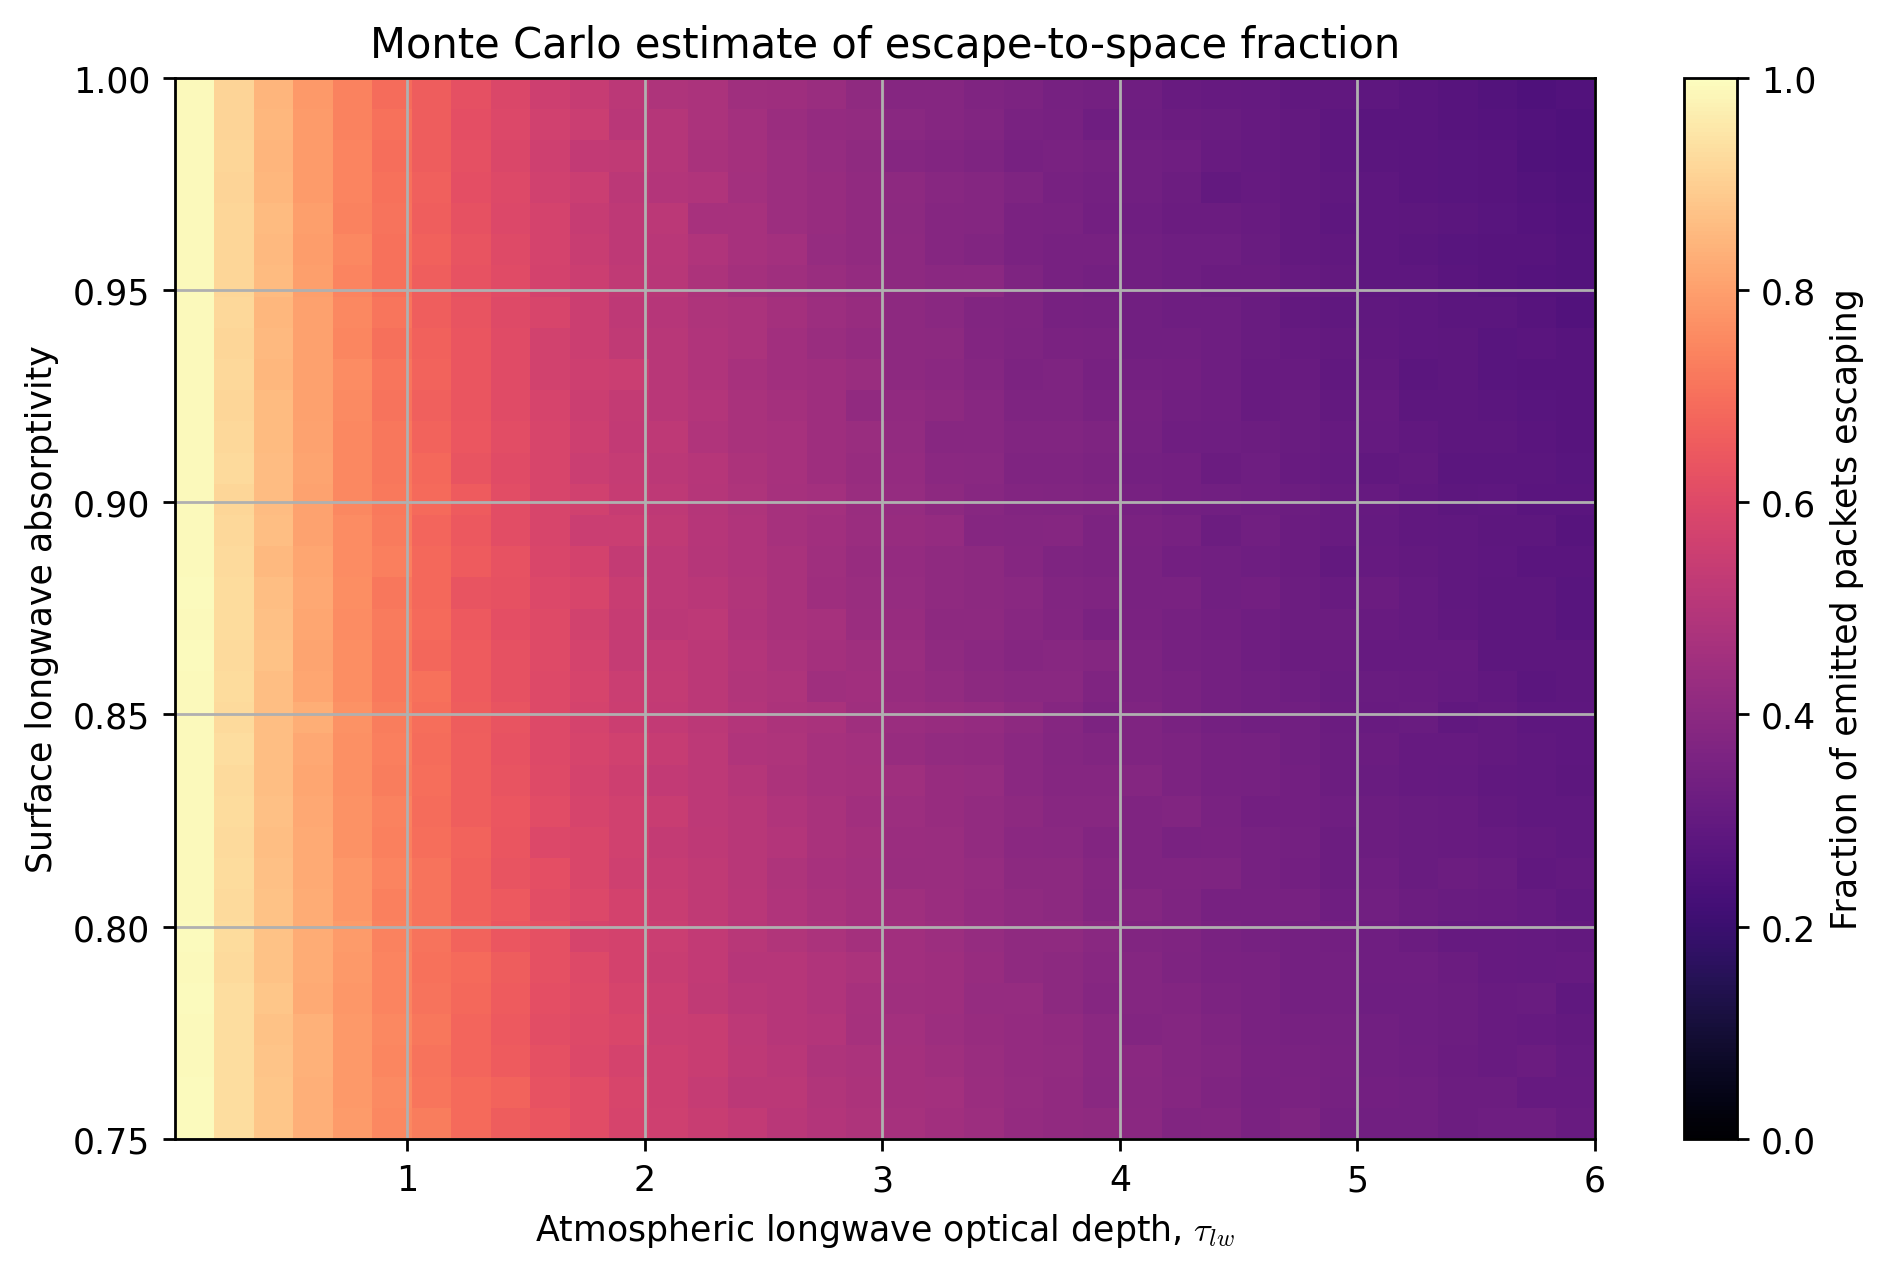

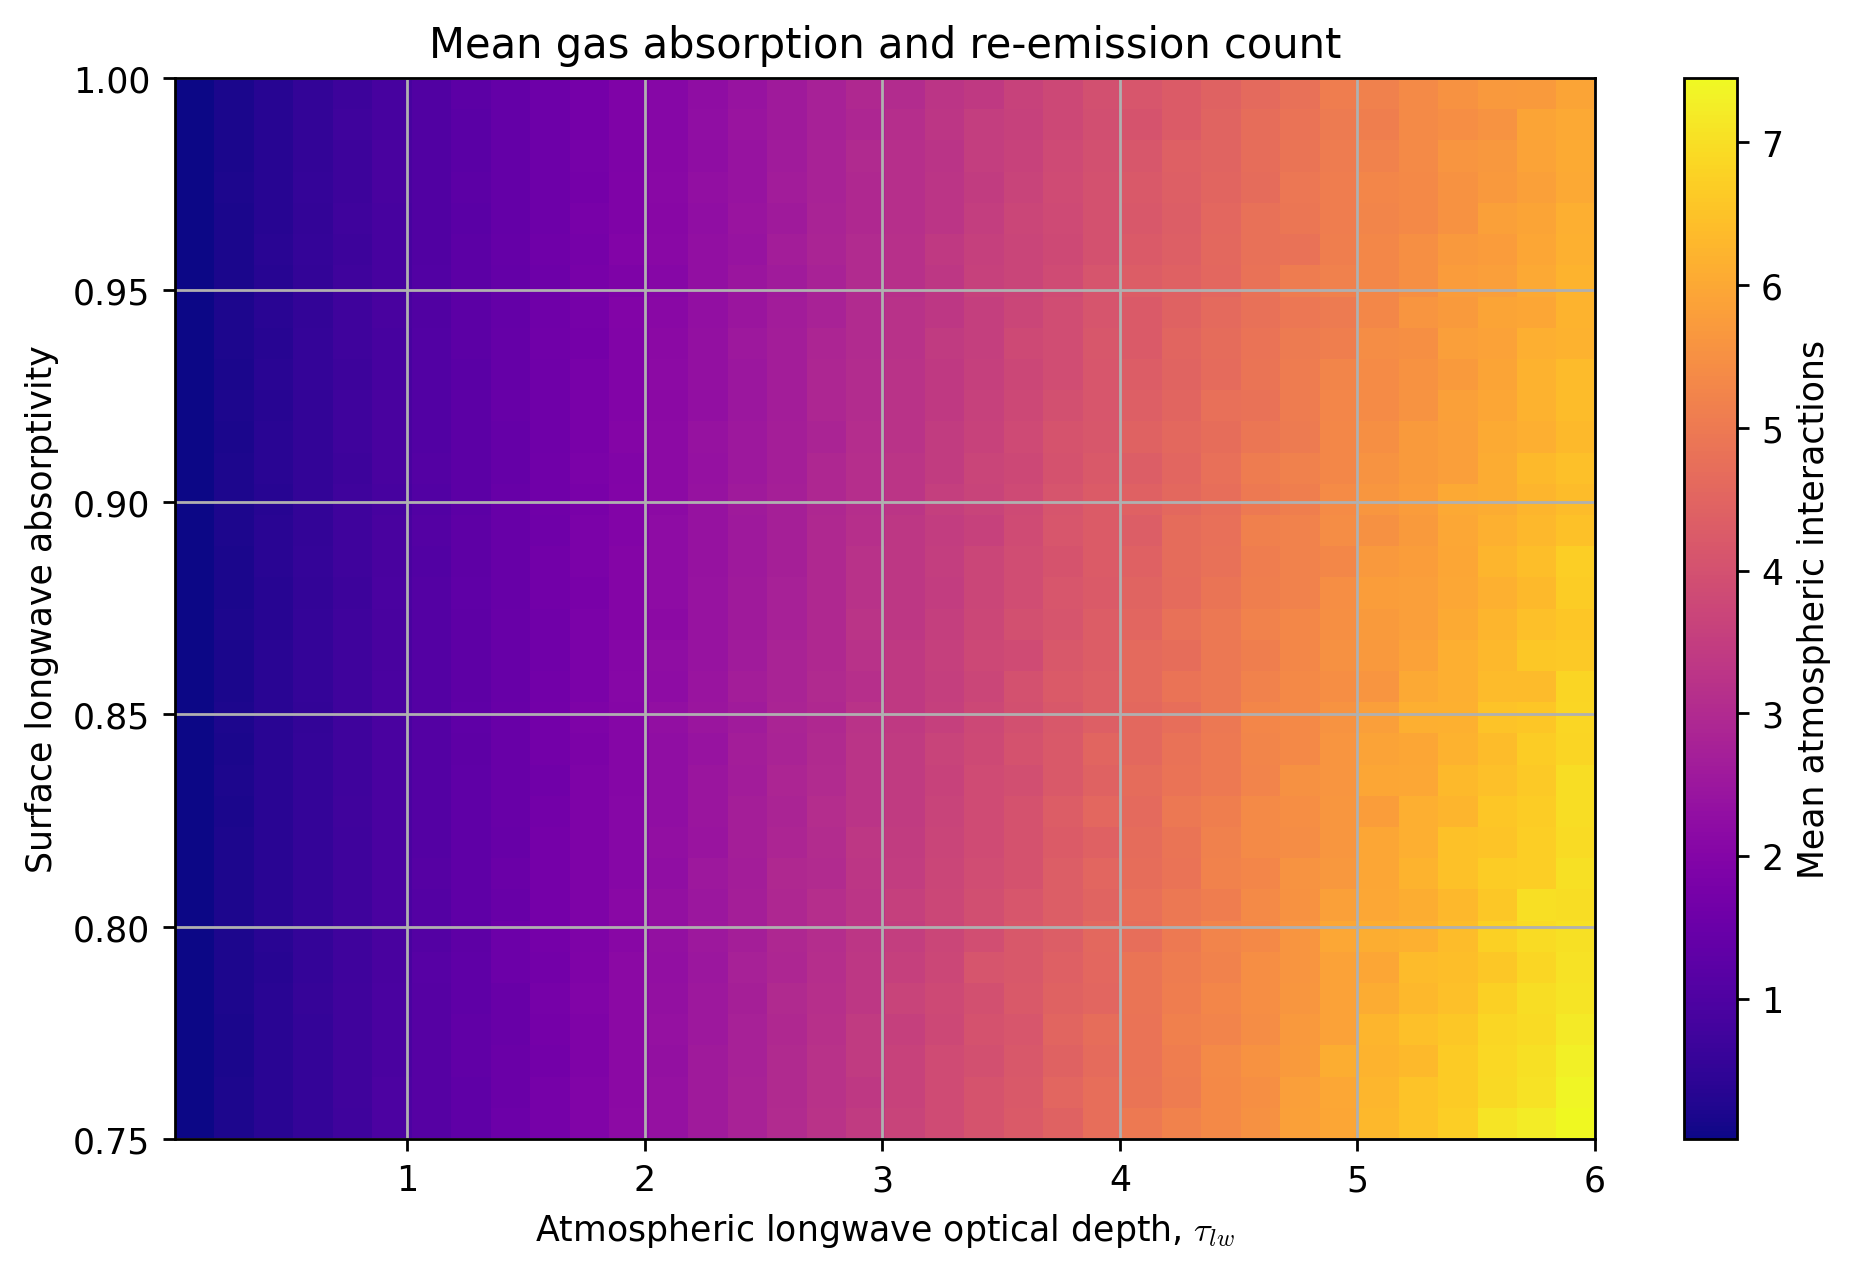

In [4]:
"""GPU Monte Carlo model of nocturnal infrared photon packets.

This cell simulates a one-dimensional gray atmosphere with absorbing and
re-emitting greenhouse gas layers. It estimates how often longwave photon
packets emitted by the surface return downward versus escaping to space.
CuPy is used automatically when a CUDA device is available.
"""


import subprocess
import sys
from typing import Any, Final

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_PACKAGES: Final[bool] = False
USE_CUPY_WHEN_AVAILABLE: Final[bool] = True
MPL_DPI: Final[int] = 250
RANDOM_SEED: Final[int] = 20260529

PACKETS_PER_GRID_POINT_GPU: Final[int] = 10_000
PACKETS_PER_GRID_POINT_CPU: Final[int] = 1_500
MAX_INTERACTIONS: Final[int] = 160
GRID_POINTS_TAU: Final[int] = 36
GRID_POINTS_SURFACE_ABS: Final[int] = 34
TAU_RANGE: Final[tuple[float, float]] = (0.02, 6.0)
SURFACE_ABSORPTIVITY_RANGE: Final[tuple[float, float]] = (0.75, 1.0)

SCENARIO_TAU_VALUES: Final[tuple[float, ...]] = (0.15, 0.60, 1.50, 3.00, 5.00)
SCENARIO_SURFACE_ABSORPTIVITY: Final[float] = 0.96

# =============================================================================
# BACKEND UTILITIES
# =============================================================================


def maybe_install_packages() -> None:
    """Install dependencies if this file is pasted as a fresh Colab cell."""
    if INSTALL_PACKAGES:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "uv"])
        subprocess.check_call(
            [
                "uv",
                "pip",
                "install",
                "--system",
                "-q",
                "numpy",
                "pandas",
                "matplotlib",
                "cupy-cuda12x",
            ]
        )


def configure_plots() -> None:
    """Configure plots for high-resolution notebook rendering."""
    mpl.rcParams["figure.dpi"] = MPL_DPI
    mpl.rcParams["savefig.dpi"] = MPL_DPI
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["mathtext.fontset"] = "cm"


def get_backend() -> tuple[Any, bool, int]:
    """Return array module, CuPy status, and packets per grid point."""
    if USE_CUPY_WHEN_AVAILABLE:
        try:
            import cupy as cp

            if cp.cuda.runtime.getDeviceCount() > 0:
                cp.random.seed(RANDOM_SEED)
                return cp, True, PACKETS_PER_GRID_POINT_GPU
        except Exception as exc:  # noqa: BLE001
            print(f"CuPy path unavailable, using NumPy CPU backend: {exc}")

    np.random.seed(RANDOM_SEED)
    return np, False, PACKETS_PER_GRID_POINT_CPU


def to_numpy(array: Any, using_cupy: bool) -> np.ndarray:
    """Convert a NumPy or CuPy array to NumPy."""
    if using_cupy:
        import cupy as cp

        return cp.asnumpy(array)
    return np.asarray(array)

# =============================================================================
# MONTE CARLO CORE
# =============================================================================


def simulate_packet_return(
    xp: Any,
    using_cupy: bool,
    optical_depth: float,
    surface_absorptivity: float,
    packet_count: int,
) -> dict[str, float]:
    """Simulate packet fate in a normalized one-dimensional atmosphere."""
    z = xp.zeros(packet_count, dtype=xp.float64)
    direction = xp.ones(packet_count, dtype=xp.float64)
    alive = xp.ones(packet_count, dtype=bool)
    returned = xp.zeros(packet_count, dtype=bool)
    escaped = xp.zeros(packet_count, dtype=bool)
    reflected = xp.zeros(packet_count, dtype=bool)
    interaction_count = xp.zeros(packet_count, dtype=xp.int32)

    optical_depth = max(float(optical_depth), 1.0e-9)

    for _ in range(MAX_INTERACTIONS):
        active_count = int(to_numpy(xp.count_nonzero(alive), using_cupy))
        if active_count == 0:
            break

        active_idx = xp.where(alive)[0]
        random_values = xp.random.random(active_count)
        optical_step = -xp.log(xp.maximum(random_values, 1.0e-12))
        dz = direction[active_idx] * optical_step / optical_depth
        z_new = z[active_idx] + dz

        hit_top = z_new >= 1.0
        hit_surface = z_new <= 0.0
        absorbed_inside = ~(hit_top | hit_surface)

        idx_top = active_idx[hit_top]
        idx_surface = active_idx[hit_surface]
        idx_absorbed = active_idx[absorbed_inside]

        escaped[idx_top] = True
        alive[idx_top] = False

        if idx_surface.size > 0:
            absorb_draw = xp.random.random(idx_surface.size)
            surface_absorbed = absorb_draw < surface_absorptivity
            idx_returned = idx_surface[surface_absorbed]
            idx_reflected = idx_surface[~surface_absorbed]
            returned[idx_returned] = True
            alive[idx_returned] = False
            reflected[idx_reflected] = True
            z[idx_reflected] = 0.0
            direction[idx_reflected] = 1.0

        if idx_absorbed.size > 0:
            z[idx_absorbed] = z_new[absorbed_inside]
            reemit_draw = xp.random.random(idx_absorbed.size)
            direction[idx_absorbed] = xp.where(reemit_draw < 0.5, -1.0, 1.0)
            interaction_count[idx_absorbed] += 1

    trapped = alive
    total = float(packet_count)
    return {
        "tau_lw": float(optical_depth),
        "surface_absorptivity": float(surface_absorptivity),
        "return_fraction": float(to_numpy(xp.mean(returned), using_cupy)),
        "escape_fraction": float(to_numpy(xp.mean(escaped), using_cupy)),
        "trapped_fraction": float(to_numpy(xp.mean(trapped), using_cupy)),
        "reflected_fraction": float(to_numpy(xp.mean(reflected), using_cupy)),
        "mean_interactions": float(to_numpy(xp.mean(interaction_count), using_cupy)),
        "packet_count": total,
    }


def build_scenario_table(xp: Any, using_cupy: bool, packet_count: int) -> pd.DataFrame:
    """Compute packet-fate statistics for selected optical depths."""
    rows = [
        simulate_packet_return(
            xp=xp,
            using_cupy=using_cupy,
            optical_depth=tau,
            surface_absorptivity=SCENARIO_SURFACE_ABSORPTIVITY,
            packet_count=packet_count,
        )
        for tau in SCENARIO_TAU_VALUES
    ]
    table = pd.DataFrame(rows)
    print("Photon-packet fate summary")
    print(table.to_string(index=False, float_format=lambda value: f"{value: .4f}"))
    return table


def build_heatmap_data(
    xp: Any,
    using_cupy: bool,
    packet_count: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute return, escape, and interaction heat maps over parameter space."""
    tau_values = np.linspace(*TAU_RANGE, GRID_POINTS_TAU)
    absorptivity_values = np.linspace(
        *SURFACE_ABSORPTIVITY_RANGE,
        GRID_POINTS_SURFACE_ABS,
    )
    return_grid = np.empty((absorptivity_values.size, tau_values.size), dtype=float)
    escape_grid = np.empty_like(return_grid)
    interaction_grid = np.empty_like(return_grid)

    for row_idx, absorptivity in enumerate(absorptivity_values):
        for col_idx, tau in enumerate(tau_values):
            result = simulate_packet_return(
                xp=xp,
                using_cupy=using_cupy,
                optical_depth=float(tau),
                surface_absorptivity=float(absorptivity),
                packet_count=packet_count,
            )
            return_grid[row_idx, col_idx] = result["return_fraction"]
            escape_grid[row_idx, col_idx] = result["escape_fraction"]
            interaction_grid[row_idx, col_idx] = result["mean_interactions"]

    return tau_values, absorptivity_values, return_grid, escape_grid, interaction_grid


def plot_heatmaps(
    tau_values: np.ndarray,
    absorptivity_values: np.ndarray,
    return_grid: np.ndarray,
    escape_grid: np.ndarray,
    interaction_grid: np.ndarray,
) -> None:
    """Render packet-return, escape, and interaction heat maps."""
    extent = [
        tau_values.min(),
        tau_values.max(),
        absorptivity_values.min(),
        absorptivity_values.max(),
    ]

    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    image = ax.imshow(
        return_grid,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )
    ax.set_xlabel(r"Atmospheric longwave optical depth, $\tau_{lw}$")
    ax.set_ylabel("Surface longwave absorptivity")
    ax.set_title("Monte Carlo estimate of downward-return fraction")
    fig.colorbar(image, ax=ax, label="Fraction of emitted packets returning to surface")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    image = ax.imshow(
        escape_grid,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="magma",
        vmin=0.0,
        vmax=1.0,
    )
    ax.set_xlabel(r"Atmospheric longwave optical depth, $\tau_{lw}$")
    ax.set_ylabel("Surface longwave absorptivity")
    ax.set_title("Monte Carlo estimate of escape-to-space fraction")
    fig.colorbar(image, ax=ax, label="Fraction of emitted packets escaping")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    image = ax.imshow(
        interaction_grid,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="plasma",
    )
    ax.set_xlabel(r"Atmospheric longwave optical depth, $\tau_{lw}$")
    ax.set_ylabel("Surface longwave absorptivity")
    ax.set_title("Mean gas absorption and re-emission count")
    fig.colorbar(image, ax=ax, label="Mean atmospheric interactions")
    plt.tight_layout()
    plt.show()


def plot_return_curve(table: pd.DataFrame) -> None:
    """Plot scenario return and escape fractions."""
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    ax.plot(table["tau_lw"], table["return_fraction"], marker="o", label="returns downward")
    ax.plot(table["tau_lw"], table["escape_fraction"], marker="s", label="escapes upward")
    ax.set_xlabel(r"Atmospheric longwave optical depth, $\tau_{lw}$")
    ax.set_ylabel("Monte Carlo packet fraction")
    ax.set_title("Packet fate shifts as atmospheric opacity increases")
    ax.legend()
    plt.tight_layout()
    plt.show()


def main() -> pd.DataFrame:
    """Run the GPU/CPU photon packet Monte Carlo model."""
    maybe_install_packages()
    configure_plots()
    xp, using_cupy, packet_count = get_backend()
    backend_name = "CuPy GPU" if using_cupy else "NumPy CPU"
    print(f"Backend: {backend_name}; packets per grid point: {packet_count}")
    table = build_scenario_table(xp, using_cupy, packet_count)
    plot_return_curve(table)
    heatmap_data = build_heatmap_data(xp, using_cupy, packet_count)
    plot_heatmaps(*heatmap_data)
    return table


if __name__ == "__main__":
    results = main()

Backend: CuPy GPU; ensemble size per grid point: 512
Reference regime summary
          case  tau_lw  h_s_W_m2_K  frost_probability  warm_night_probability  mean_min_temp_C  p10_min_temp_C  mean_cooling_rate_K_per_h
      dry calm  0.2057      0.9787             0.0352                  0.0000           8.2753          2.0593                    -0.3794
      baseline  0.7245      3.8723             0.0059                  0.0059           9.9387          4.4612                    -0.2267
    humid calm  1.5028      2.1362             0.0020                  0.0176          11.2456          5.2267                    -0.1042
   humid windy  1.5028      9.9489             0.0039                  0.0176          11.1799          5.4612                    -0.1214
infrared-thick  2.4887      3.8723             0.0098                  0.0488          12.1960          6.3060                    -0.0508


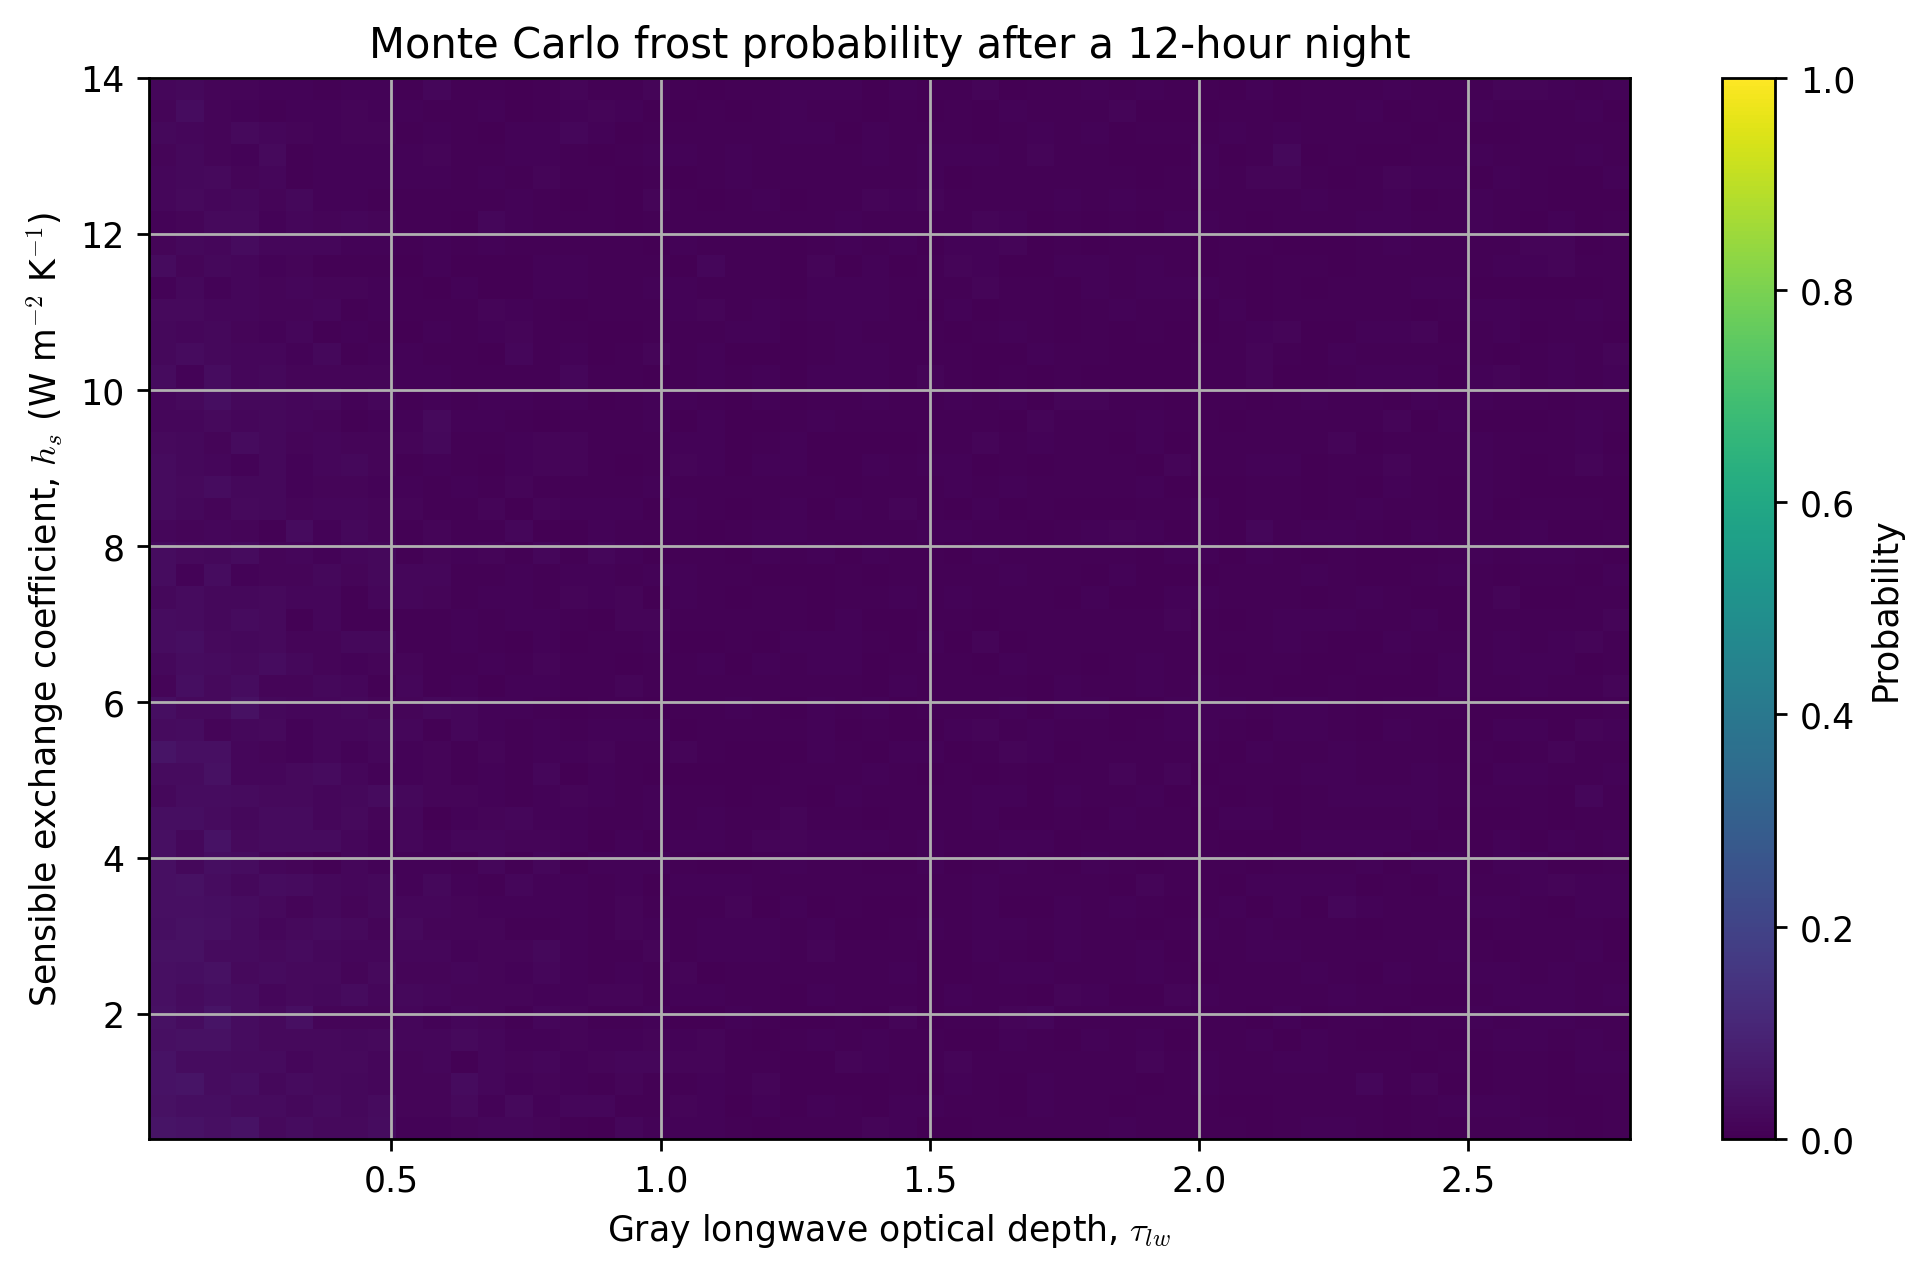

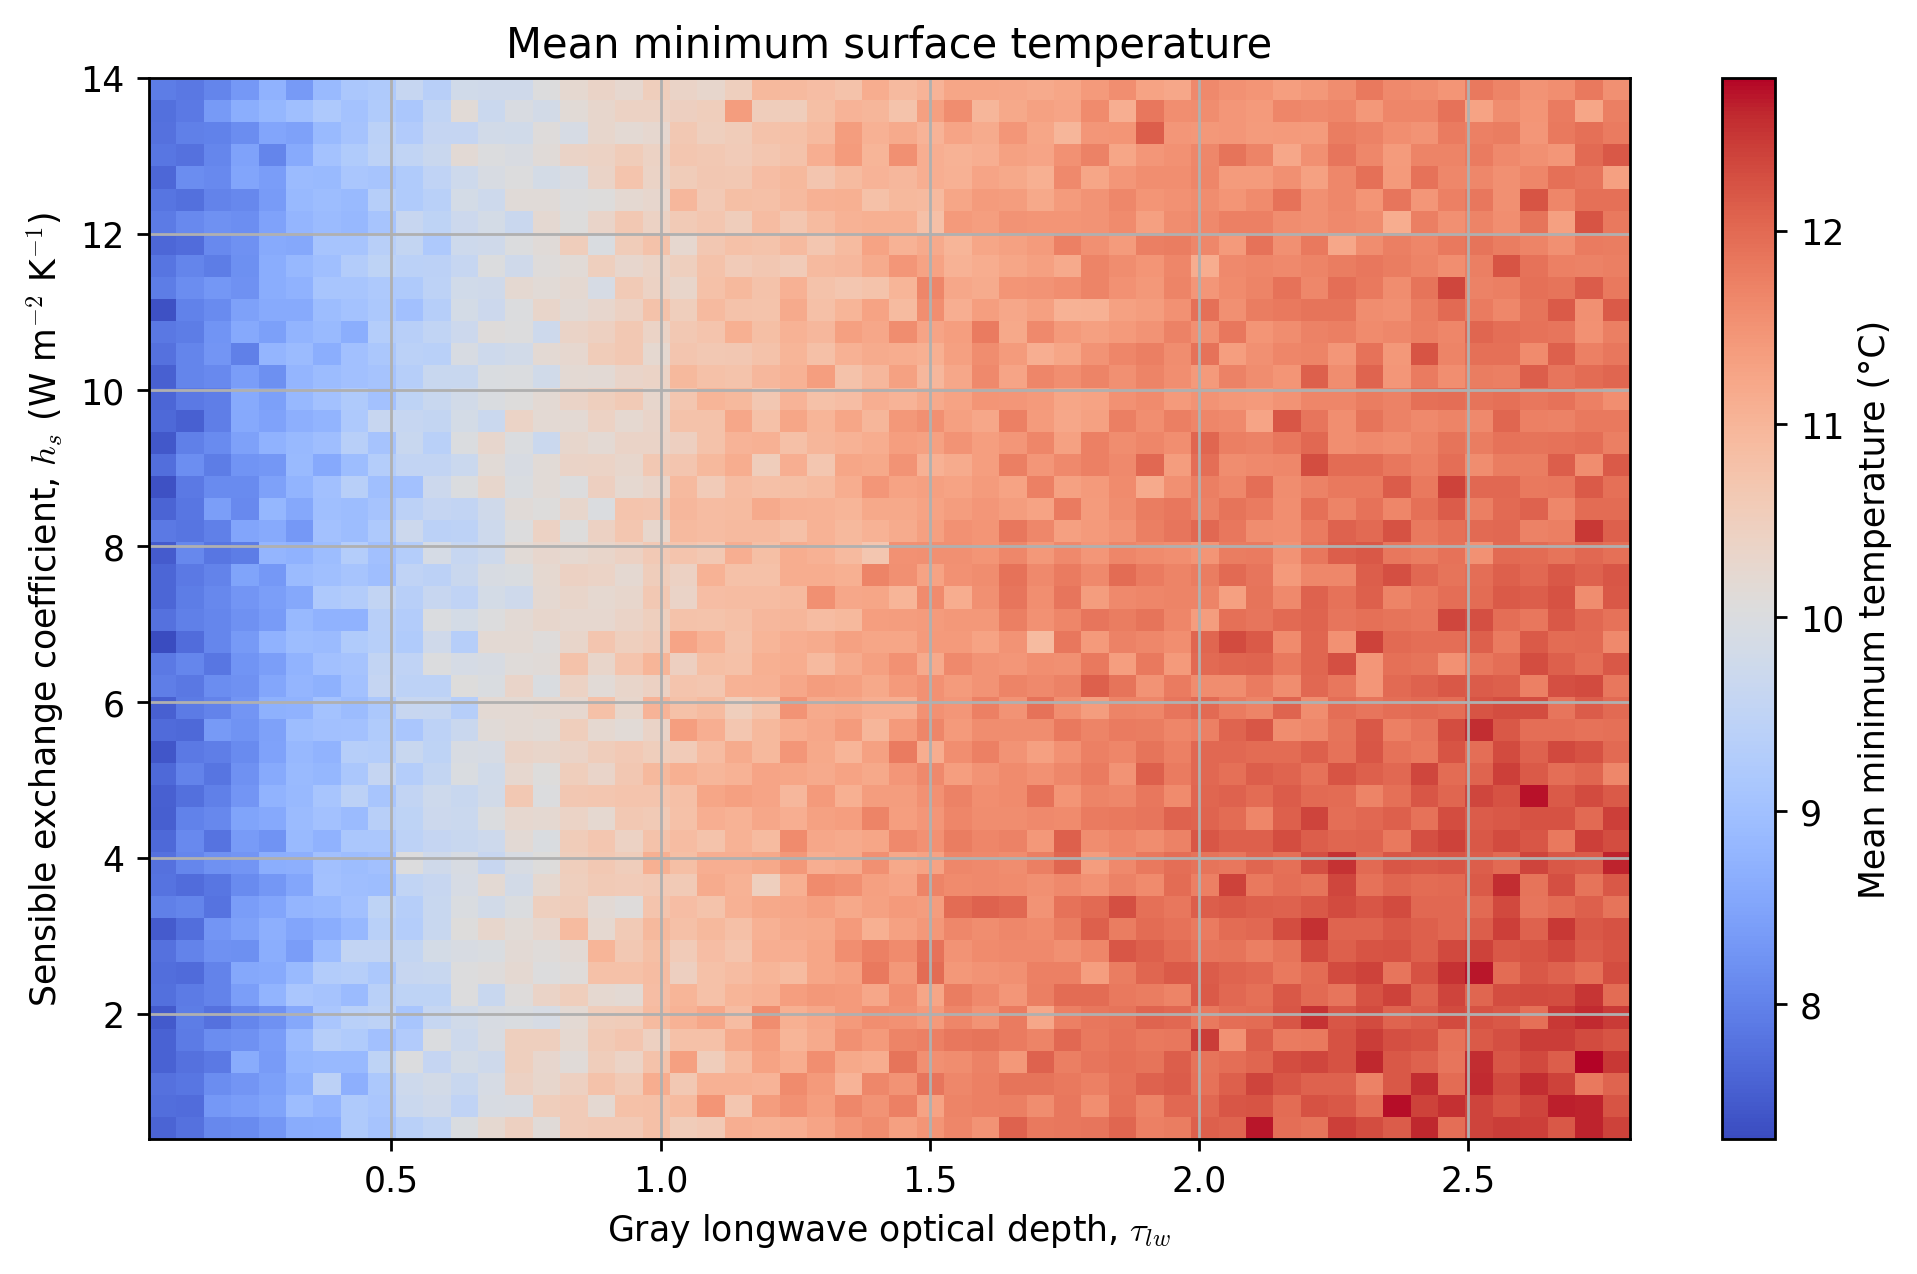

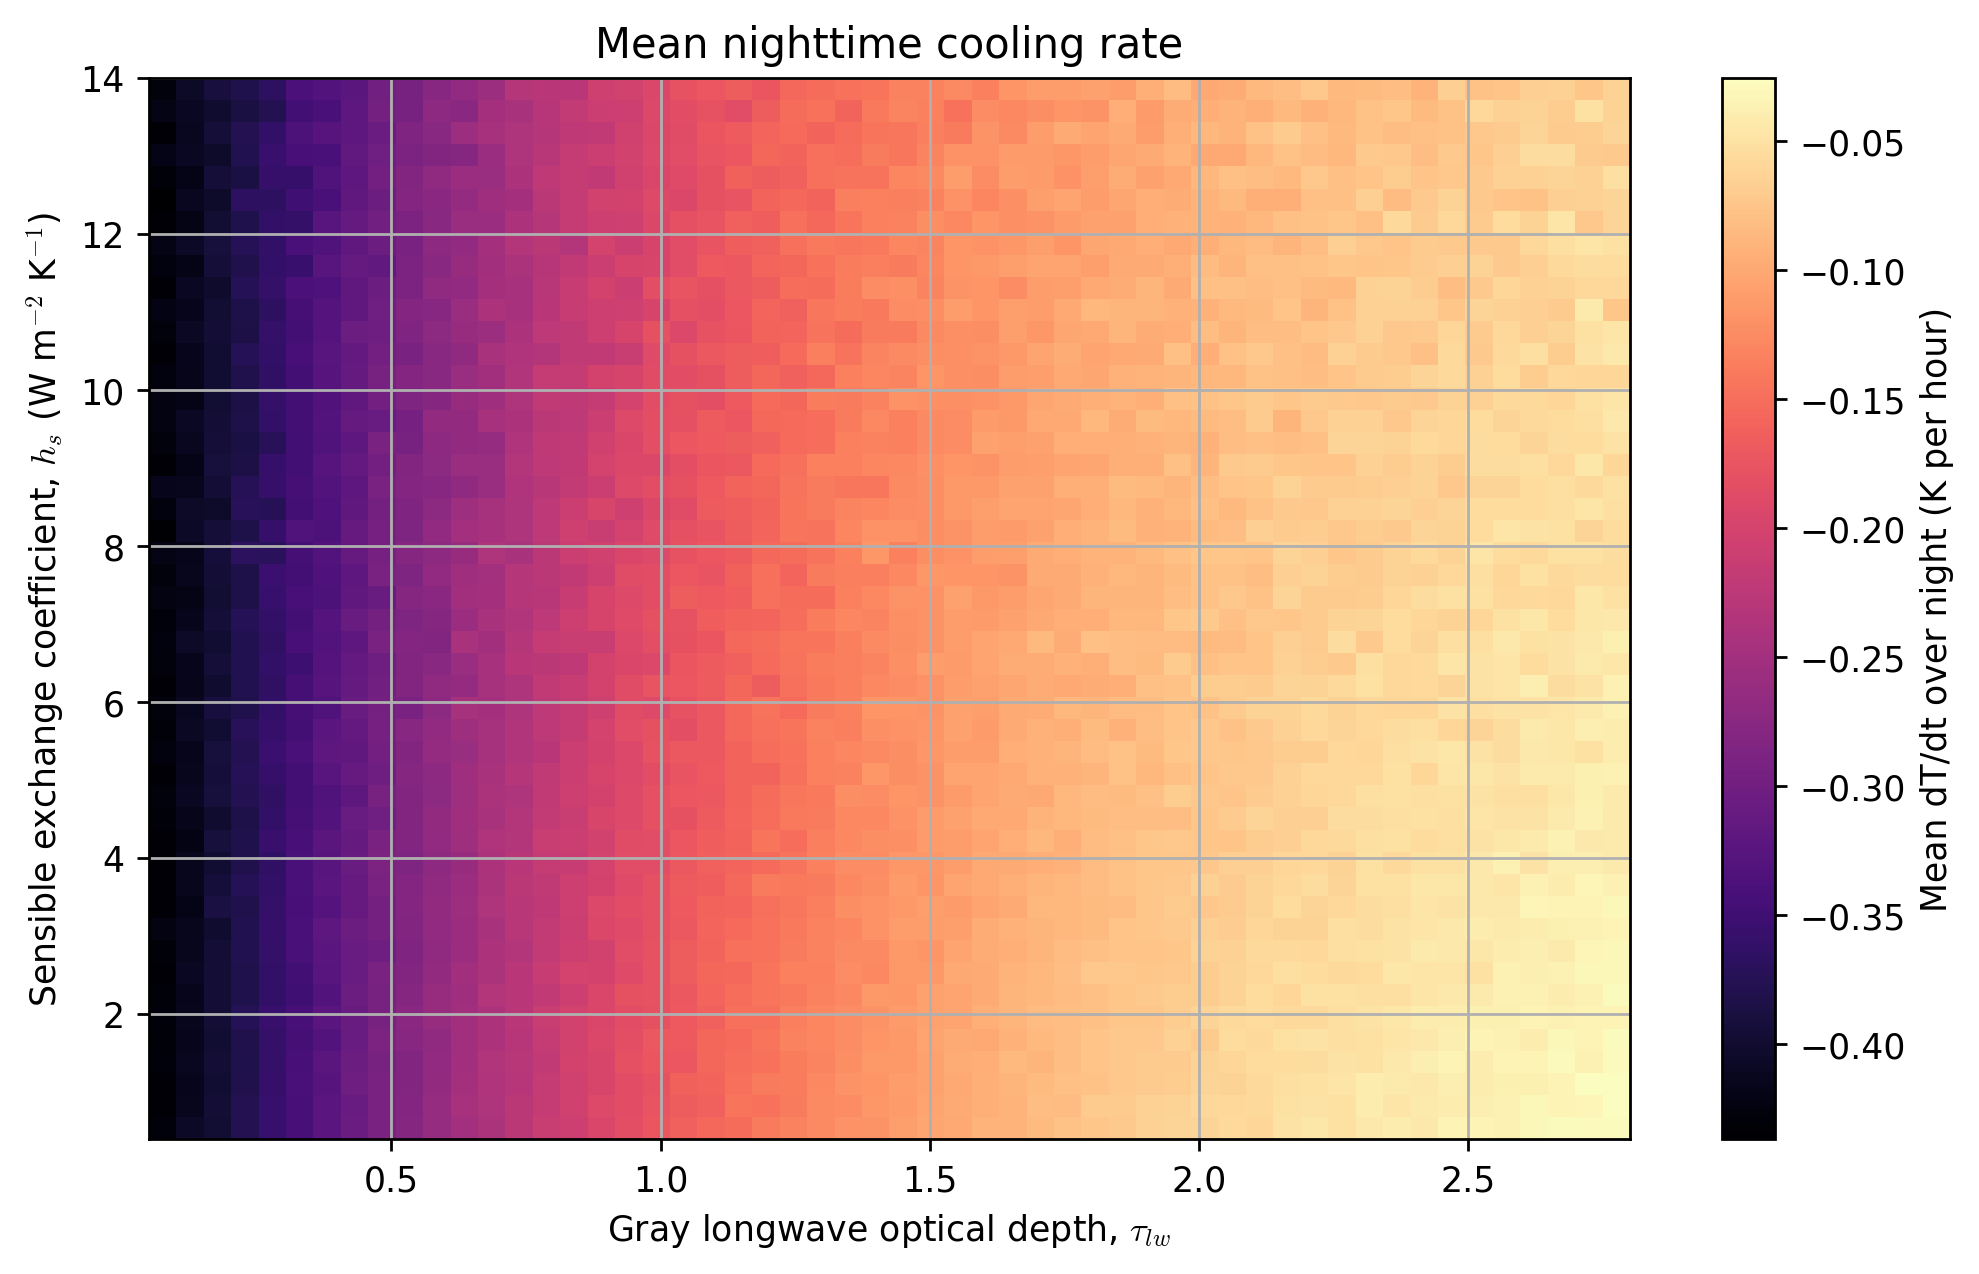

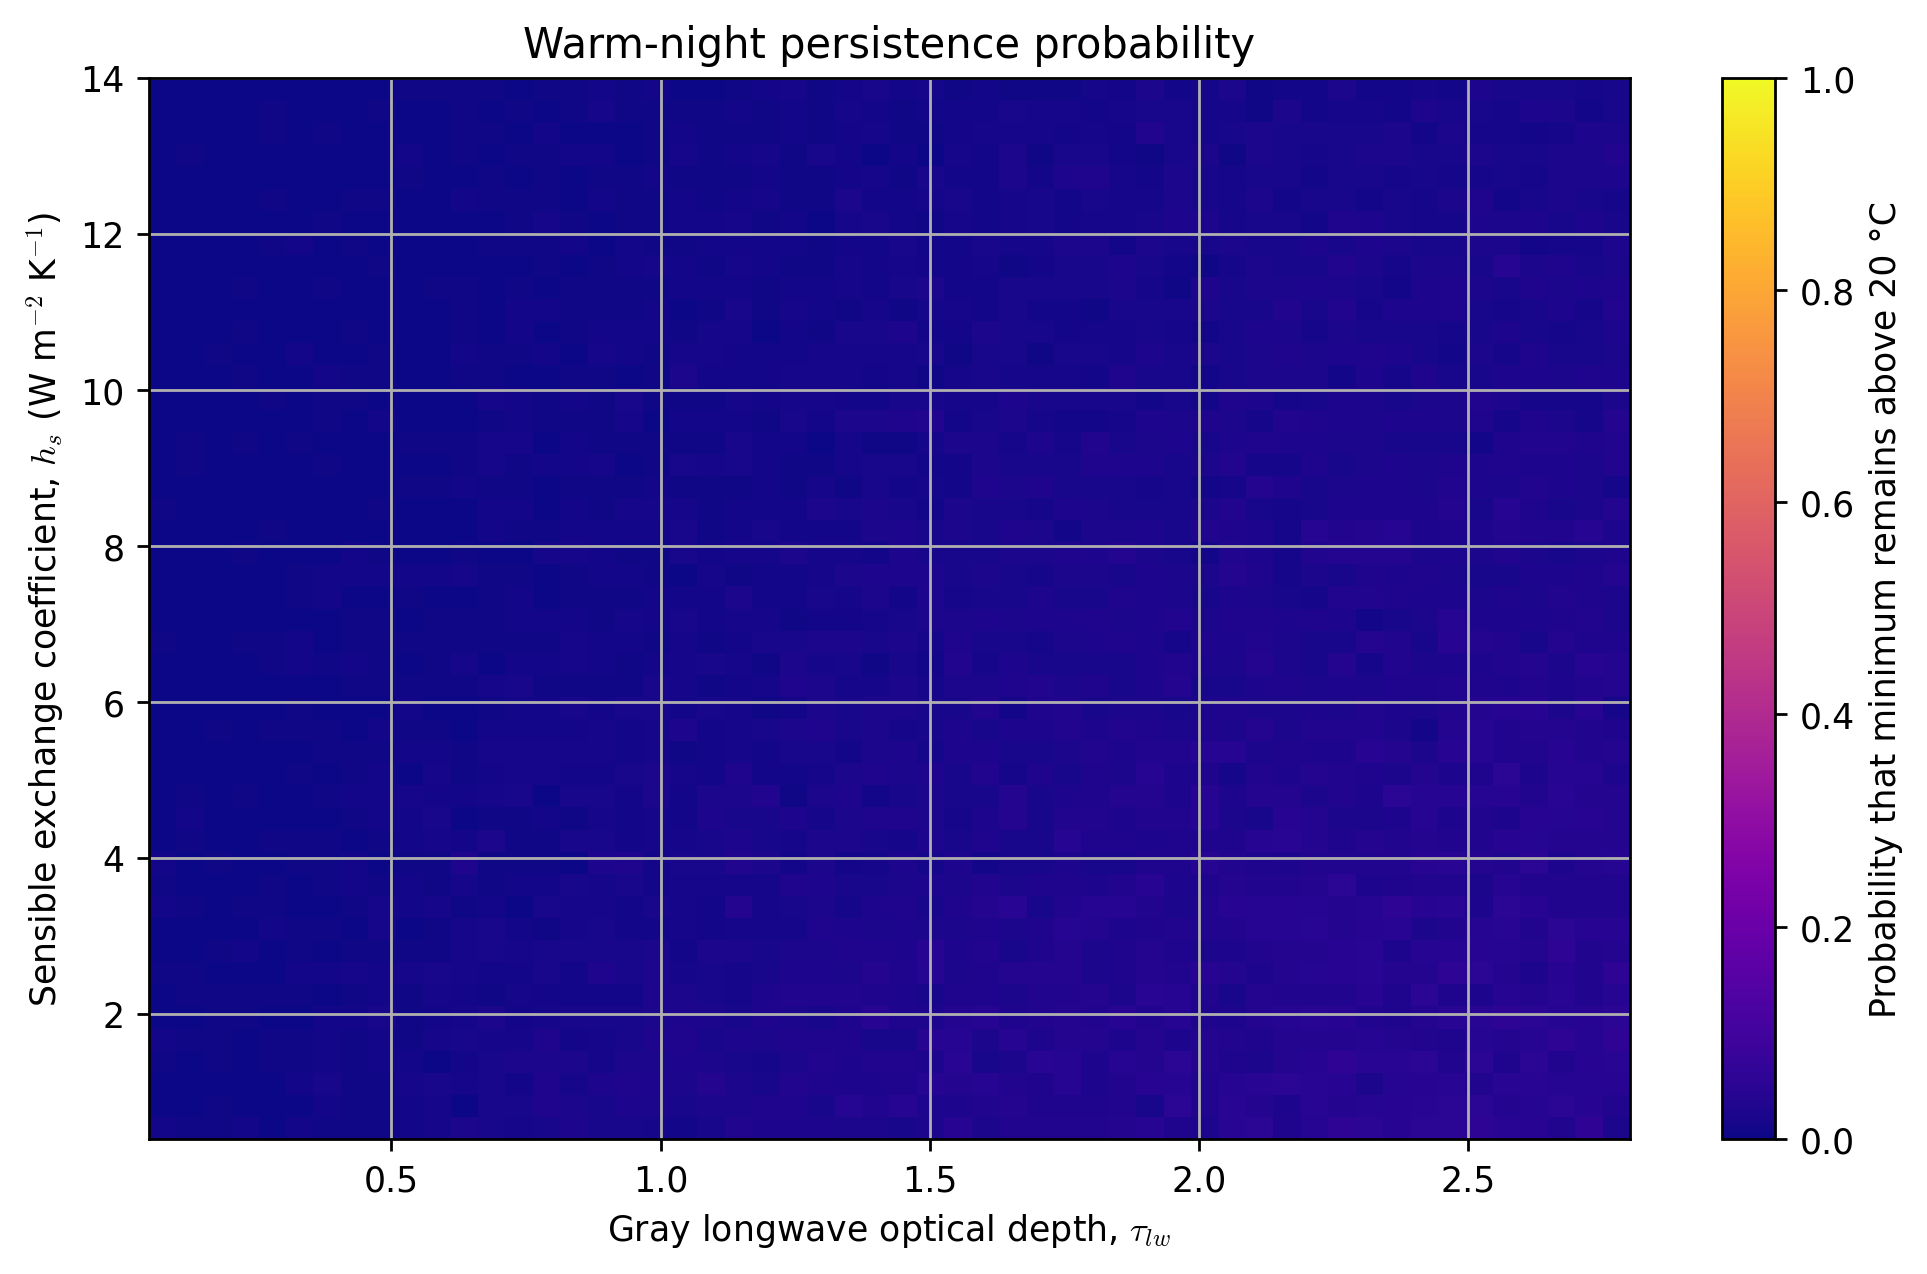

In [5]:
"""GPU ensemble heat maps for nocturnal surface-energy outcomes.

This cell performs a vectorized Monte Carlo ensemble of nighttime surface
cooling trajectories. It estimates frost probability, warm-night persistence,
minimum temperature, and cooling rate across longwave opacity and turbulent
mixing regimes. CuPy accelerates the ensemble when a CUDA device is available.
"""


import subprocess
import sys
from typing import Any, Final

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_PACKAGES: Final[bool] = False
USE_CUPY_WHEN_AVAILABLE: Final[bool] = True
MPL_DPI: Final[int] = 250
RANDOM_SEED: Final[int] = 20260529

SIGMA_SB: Final[float] = 5.670374419e-8
SURFACE_EMISSIVITY: Final[float] = 0.96
SURFACE_HEAT_CAPACITY: Final[float] = 2.7e6
GROUND_COEFFICIENT: Final[float] = 1.2
NIGHT_HOURS: Final[float] = 12.0
TIME_STEP_SECONDS: Final[float] = 120.0

GRID_POINTS_TAU: Final[int] = 54
GRID_POINTS_MIXING: Final[int] = 48
ENSEMBLE_SIZE_GPU: Final[int] = 512
ENSEMBLE_SIZE_CPU: Final[int] = 128
TAU_RANGE: Final[tuple[float, float]] = (0.05, 2.80)
MIXING_RANGE_W_M2_K: Final[tuple[float, float]] = (0.4, 14.0)

MEAN_INITIAL_SURFACE_TEMP_K: Final[float] = 286.0
STD_INITIAL_SURFACE_TEMP_K: Final[float] = 5.0
MEAN_AIR_TEMP_K: Final[float] = 283.5
STD_AIR_TEMP_K: Final[float] = 4.0
MEAN_DEEP_GROUND_TEMP_K: Final[float] = 286.0
STD_DEEP_GROUND_TEMP_K: Final[float] = 2.0
RANDOM_HUMIDITY_TAU_STD: Final[float] = 0.12
RANDOM_MIXING_LOG_STD: Final[float] = 0.22

FROST_THRESHOLD_K: Final[float] = 273.15
WARM_NIGHT_THRESHOLD_K: Final[float] = 293.15

# =============================================================================
# UTILITIES
# =============================================================================


def maybe_install_packages() -> None:
    """Install dependencies if this file is pasted as a fresh Colab cell."""
    if INSTALL_PACKAGES:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "uv"])
        subprocess.check_call(
            [
                "uv",
                "pip",
                "install",
                "--system",
                "-q",
                "numpy",
                "pandas",
                "matplotlib",
                "cupy-cuda12x",
            ]
        )


def configure_plots() -> None:
    """Configure Matplotlib for Colab rendering."""
    mpl.rcParams["figure.dpi"] = MPL_DPI
    mpl.rcParams["savefig.dpi"] = MPL_DPI
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["mathtext.fontset"] = "cm"


def get_backend() -> tuple[Any, bool, int]:
    """Return array module, CuPy status, and ensemble size."""
    if USE_CUPY_WHEN_AVAILABLE:
        try:
            import cupy as cp

            if cp.cuda.runtime.getDeviceCount() > 0:
                cp.random.seed(RANDOM_SEED)
                return cp, True, ENSEMBLE_SIZE_GPU
        except Exception as exc:  # noqa: BLE001
            print(f"CuPy path unavailable, using NumPy CPU backend: {exc}")

    np.random.seed(RANDOM_SEED)
    return np, False, ENSEMBLE_SIZE_CPU


def to_numpy(array: Any, using_cupy: bool) -> np.ndarray:
    """Convert NumPy or CuPy arrays to NumPy arrays."""
    if using_cupy:
        import cupy as cp

        return cp.asnumpy(array)
    return np.asarray(array)


def air_emissivity(xp: Any, optical_depth: Any) -> Any:
    """Map optical depth to gray atmospheric emissivity."""
    return 1.0 - xp.exp(-optical_depth)

# =============================================================================
# ENSEMBLE MODEL
# =============================================================================


def simulate_ensemble_grid(
    xp: Any,
    using_cupy: bool,
    ensemble_size: int,
) -> tuple[np.ndarray, np.ndarray, dict[str, np.ndarray]]:
    """Simulate nighttime cooling outcomes over opacity and mixing grids."""
    tau_values = xp.linspace(TAU_RANGE[0], TAU_RANGE[1], GRID_POINTS_TAU)
    mixing_values = xp.linspace(
        MIXING_RANGE_W_M2_K[0],
        MIXING_RANGE_W_M2_K[1],
        GRID_POINTS_MIXING,
    )
    tau_grid, mixing_grid = xp.meshgrid(tau_values, mixing_values)
    grid_shape = tau_grid.shape
    sample_shape = grid_shape + (ensemble_size,)

    initial_noise = xp.random.normal(0.0, STD_INITIAL_SURFACE_TEMP_K, sample_shape)
    air_noise = xp.random.normal(0.0, STD_AIR_TEMP_K, sample_shape)
    ground_noise = xp.random.normal(0.0, STD_DEEP_GROUND_TEMP_K, sample_shape)
    tau_noise = xp.random.normal(0.0, RANDOM_HUMIDITY_TAU_STD, sample_shape)
    mixing_noise = xp.random.normal(0.0, RANDOM_MIXING_LOG_STD, sample_shape)

    surface_temp = MEAN_INITIAL_SURFACE_TEMP_K + initial_noise
    min_temp = surface_temp.copy()
    air_temp = MEAN_AIR_TEMP_K + air_noise
    ground_temp = MEAN_DEEP_GROUND_TEMP_K + ground_noise
    tau_samples = xp.maximum(tau_grid[..., None] + tau_noise, 0.005)
    mixing_samples = mixing_grid[..., None] * xp.exp(mixing_noise)

    start_temp = surface_temp.copy()
    steps = int(round(NIGHT_HOURS * 3600.0 / TIME_STEP_SECONDS))

    for _ in range(steps):
        longwave_down = air_emissivity(xp, tau_samples) * SIGMA_SB * air_temp**4
        longwave_up = SURFACE_EMISSIVITY * SIGMA_SB * surface_temp**4
        sensible = mixing_samples * (air_temp - surface_temp)
        ground = GROUND_COEFFICIENT * (ground_temp - surface_temp)
        net_flux = longwave_down - longwave_up + sensible + ground
        surface_temp = surface_temp + TIME_STEP_SECONDS * net_flux / SURFACE_HEAT_CAPACITY
        min_temp = xp.minimum(min_temp, surface_temp)

    cooling_rate = (surface_temp - start_temp) / NIGHT_HOURS
    frost_probability = xp.mean(min_temp < FROST_THRESHOLD_K, axis=-1)
    warm_night_probability = xp.mean(min_temp > WARM_NIGHT_THRESHOLD_K, axis=-1)
    mean_min_temp = xp.mean(min_temp, axis=-1)
    mean_final_temp = xp.mean(surface_temp, axis=-1)
    mean_cooling_rate = xp.mean(cooling_rate, axis=-1)
    p10_min_temp = xp.percentile(min_temp, 10, axis=-1)

    outputs = {
        "frost_probability": to_numpy(frost_probability, using_cupy),
        "warm_night_probability": to_numpy(warm_night_probability, using_cupy),
        "mean_min_temp_C": to_numpy(mean_min_temp - 273.15, using_cupy),
        "mean_final_temp_C": to_numpy(mean_final_temp - 273.15, using_cupy),
        "mean_cooling_rate_K_per_h": to_numpy(mean_cooling_rate, using_cupy),
        "p10_min_temp_C": to_numpy(p10_min_temp - 273.15, using_cupy),
    }
    return to_numpy(tau_values, using_cupy), to_numpy(mixing_values, using_cupy), outputs


def summarize_reference_points(
    tau_values: np.ndarray,
    mixing_values: np.ndarray,
    outputs: dict[str, np.ndarray],
) -> pd.DataFrame:
    """Summarize selected grid points for quick interpretation."""
    selected = [
        (0.20, 1.0, "dry calm"),
        (0.75, 4.0, "baseline"),
        (1.50, 2.0, "humid calm"),
        (1.50, 10.0, "humid windy"),
        (2.50, 4.0, "infrared-thick"),
    ]
    rows: list[dict[str, float | str]] = []
    for tau_target, mixing_target, label in selected:
        tau_idx = int(np.argmin(np.abs(tau_values - tau_target)))
        mixing_idx = int(np.argmin(np.abs(mixing_values - mixing_target)))
        rows.append(
            {
                "case": label,
                "tau_lw": tau_values[tau_idx],
                "h_s_W_m2_K": mixing_values[mixing_idx],
                "frost_probability": outputs["frost_probability"][mixing_idx, tau_idx],
                "warm_night_probability": outputs["warm_night_probability"][mixing_idx, tau_idx],
                "mean_min_temp_C": outputs["mean_min_temp_C"][mixing_idx, tau_idx],
                "p10_min_temp_C": outputs["p10_min_temp_C"][mixing_idx, tau_idx],
                "mean_cooling_rate_K_per_h": outputs["mean_cooling_rate_K_per_h"][mixing_idx, tau_idx],
            }
        )
    table = pd.DataFrame(rows)
    print("Reference regime summary")
    print(table.to_string(index=False, float_format=lambda value: f"{value: .4f}"))
    return table


def plot_heatmap(
    tau_values: np.ndarray,
    mixing_values: np.ndarray,
    grid: np.ndarray,
    title: str,
    colorbar_label: str,
    cmap: str,
    vmin: float | None = None,
    vmax: float | None = None,
) -> None:
    """Render one heat map over opacity and mixing."""
    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    image = ax.imshow(
        grid,
        origin="lower",
        aspect="auto",
        extent=[
            tau_values.min(),
            tau_values.max(),
            mixing_values.min(),
            mixing_values.max(),
        ],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xlabel(r"Gray longwave optical depth, $\tau_{lw}$")
    ax.set_ylabel(r"Sensible exchange coefficient, $h_s$ (W m$^{-2}$ K$^{-1}$)")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label=colorbar_label)
    plt.tight_layout()
    plt.show()


def plot_all_heatmaps(
    tau_values: np.ndarray,
    mixing_values: np.ndarray,
    outputs: dict[str, np.ndarray],
) -> None:
    """Render the complete ensemble heat-map set."""
    plot_heatmap(
        tau_values,
        mixing_values,
        outputs["frost_probability"],
        "Monte Carlo frost probability after a 12-hour night",
        "Probability",
        "viridis",
        0.0,
        1.0,
    )
    plot_heatmap(
        tau_values,
        mixing_values,
        outputs["mean_min_temp_C"],
        "Mean minimum surface temperature",
        "Mean minimum temperature (°C)",
        "coolwarm",
    )
    plot_heatmap(
        tau_values,
        mixing_values,
        outputs["mean_cooling_rate_K_per_h"],
        "Mean nighttime cooling rate",
        "Mean dT/dt over night (K per hour)",
        "magma",
    )
    plot_heatmap(
        tau_values,
        mixing_values,
        outputs["warm_night_probability"],
        "Warm-night persistence probability",
        "Probability that minimum remains above 20 °C",
        "plasma",
        0.0,
        1.0,
    )


def main() -> pd.DataFrame:
    """Run the ensemble model and render all heat maps."""
    maybe_install_packages()
    configure_plots()
    xp, using_cupy, ensemble_size = get_backend()
    backend_name = "CuPy GPU" if using_cupy else "NumPy CPU"
    print(f"Backend: {backend_name}; ensemble size per grid point: {ensemble_size}")
    tau_values, mixing_values, outputs = simulate_ensemble_grid(
        xp=xp,
        using_cupy=using_cupy,
        ensemble_size=ensemble_size,
    )
    table = summarize_reference_points(tau_values, mixing_values, outputs)
    plot_all_heatmaps(tau_values, mixing_values, outputs)
    return table


if __name__ == "__main__":
    results = main()

Synthesis-regime table
                   regime  mean_night_C  tau_lw  buffer_K  cold_benefit  warm_penalty  net_index
high-elevation cold night       -5.8994  1.0025    3.1998        0.1626        0.0002     0.1624
     marginal frost night        0.9050  1.0025    3.1998        0.2646        0.0023     0.2619
     temperate mild night       10.0559  1.0025    3.1998        0.0078        0.0546    -0.0550
         humid warm night       22.0223  1.6017    4.1339        0.0000        0.2270    -0.2610
        desert warm night       25.0726  0.4955    1.9254        0.0000        0.0645    -0.0742


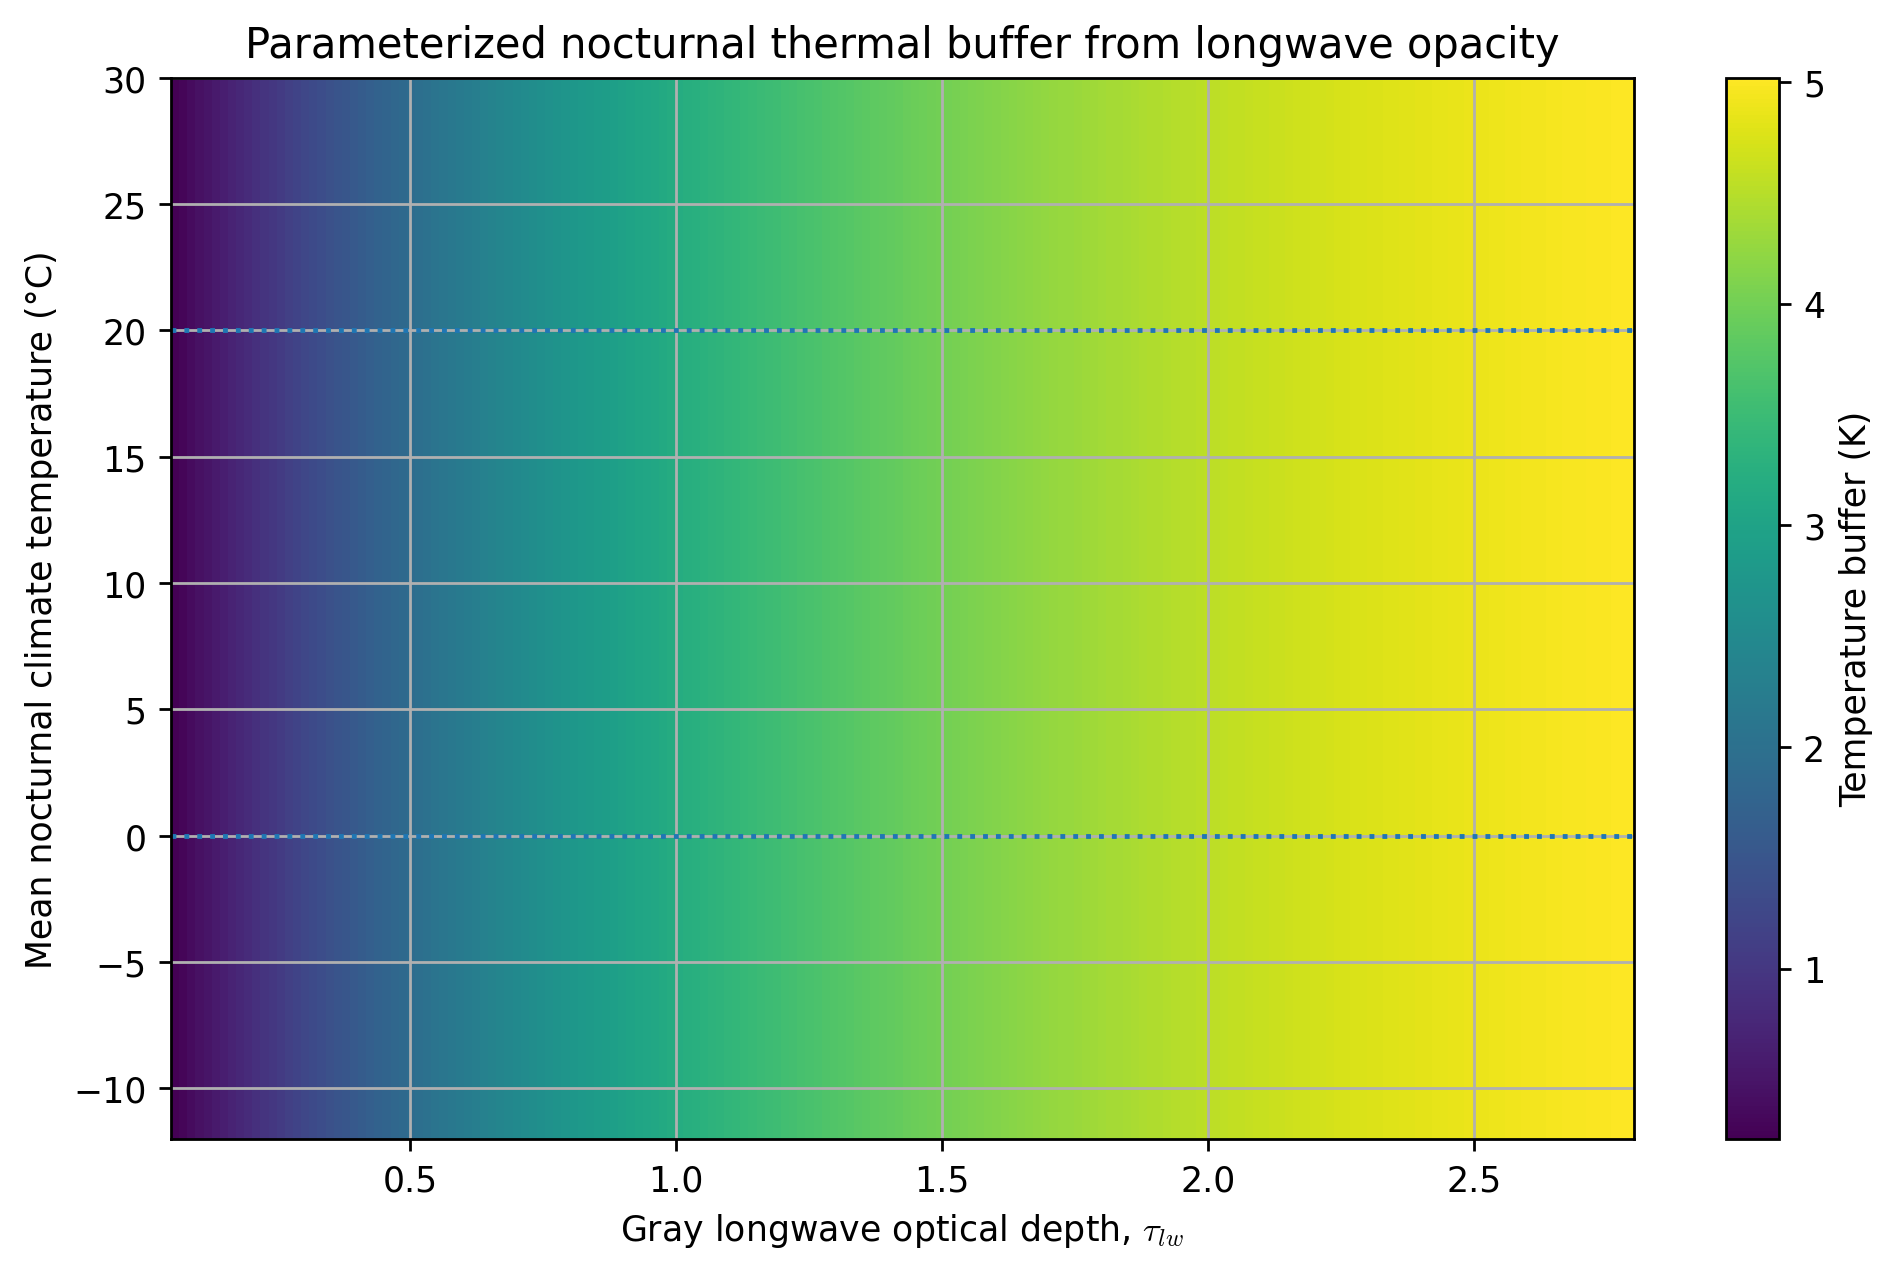

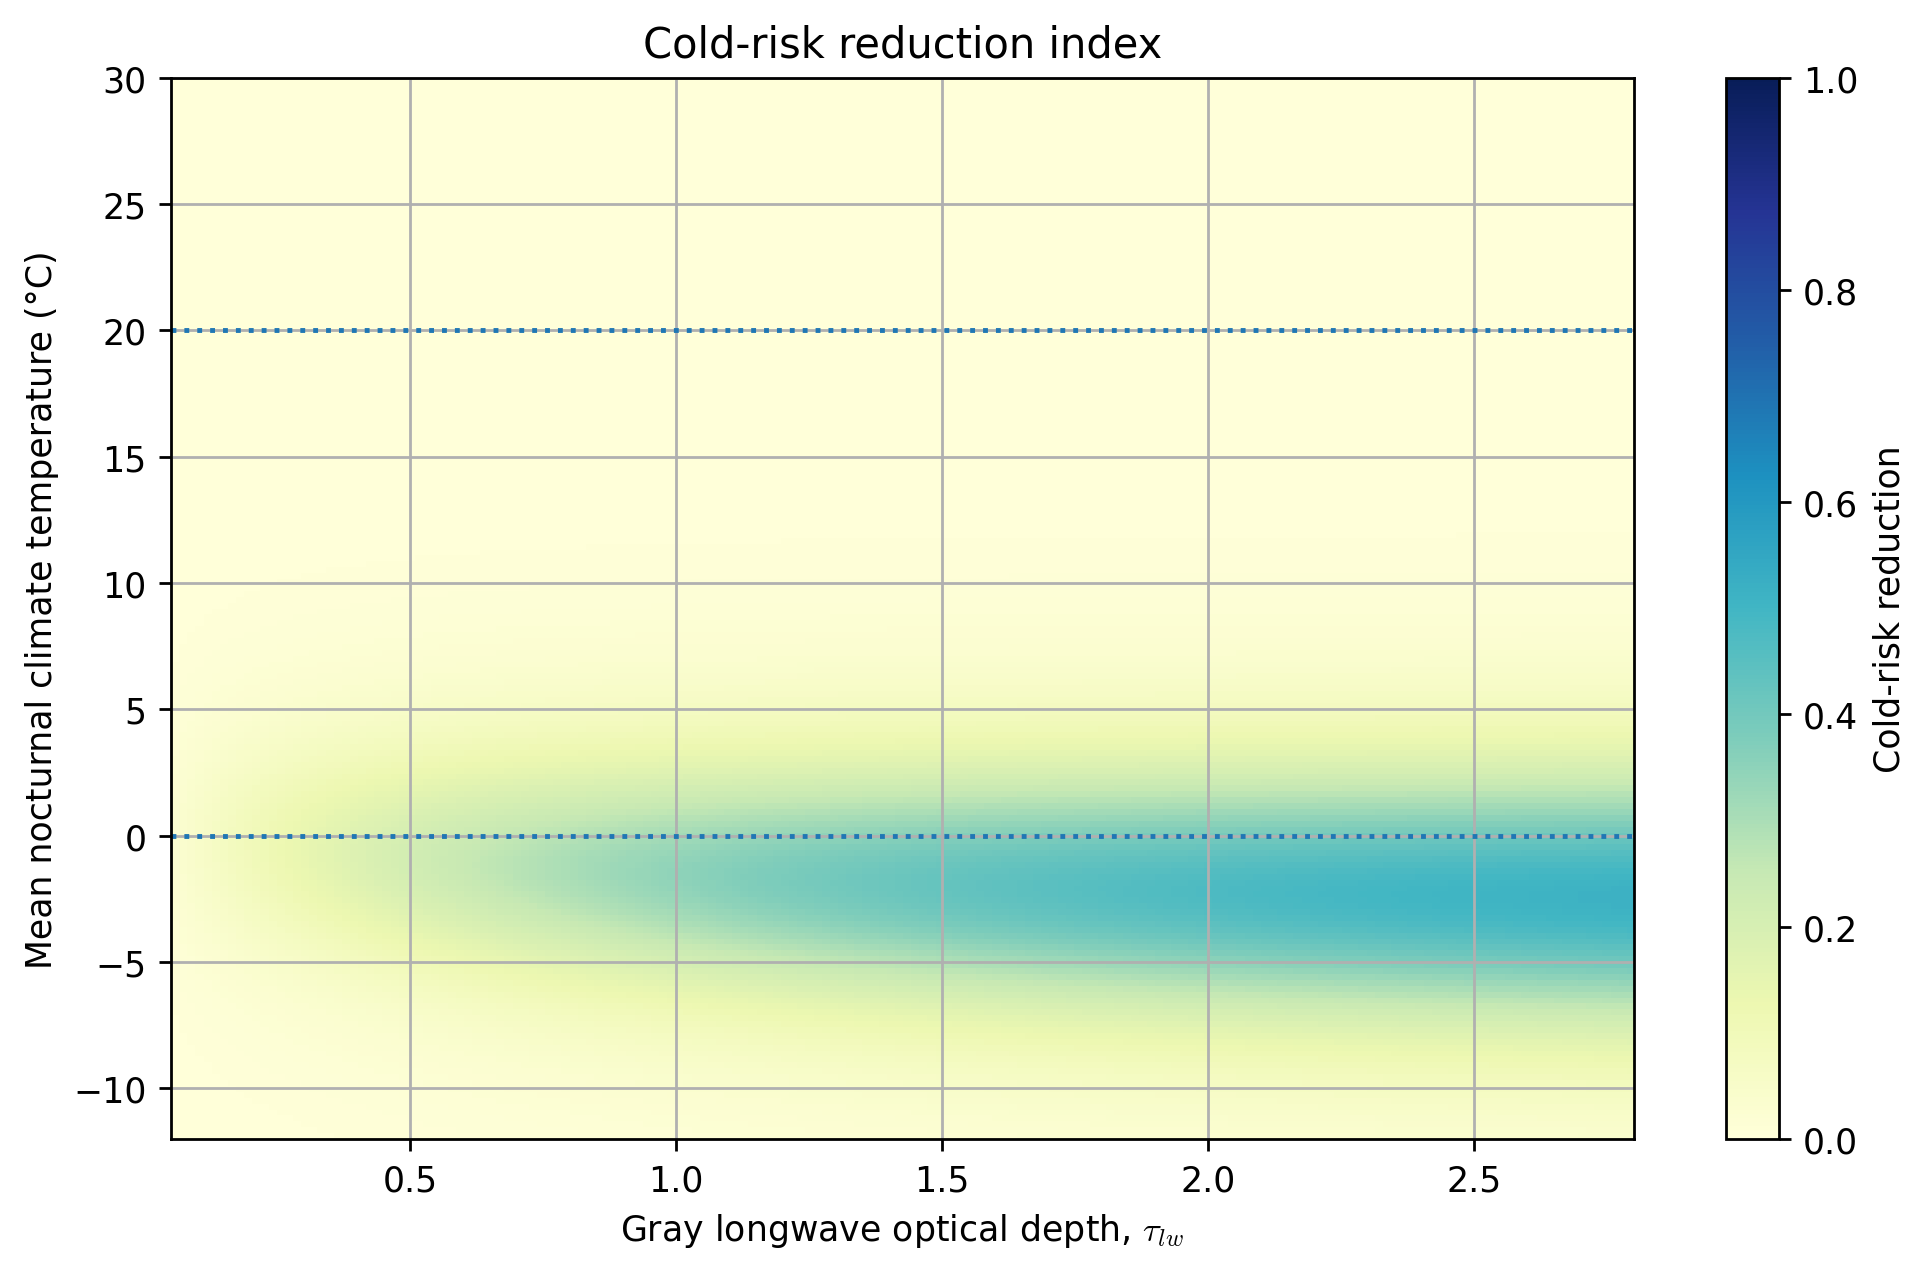

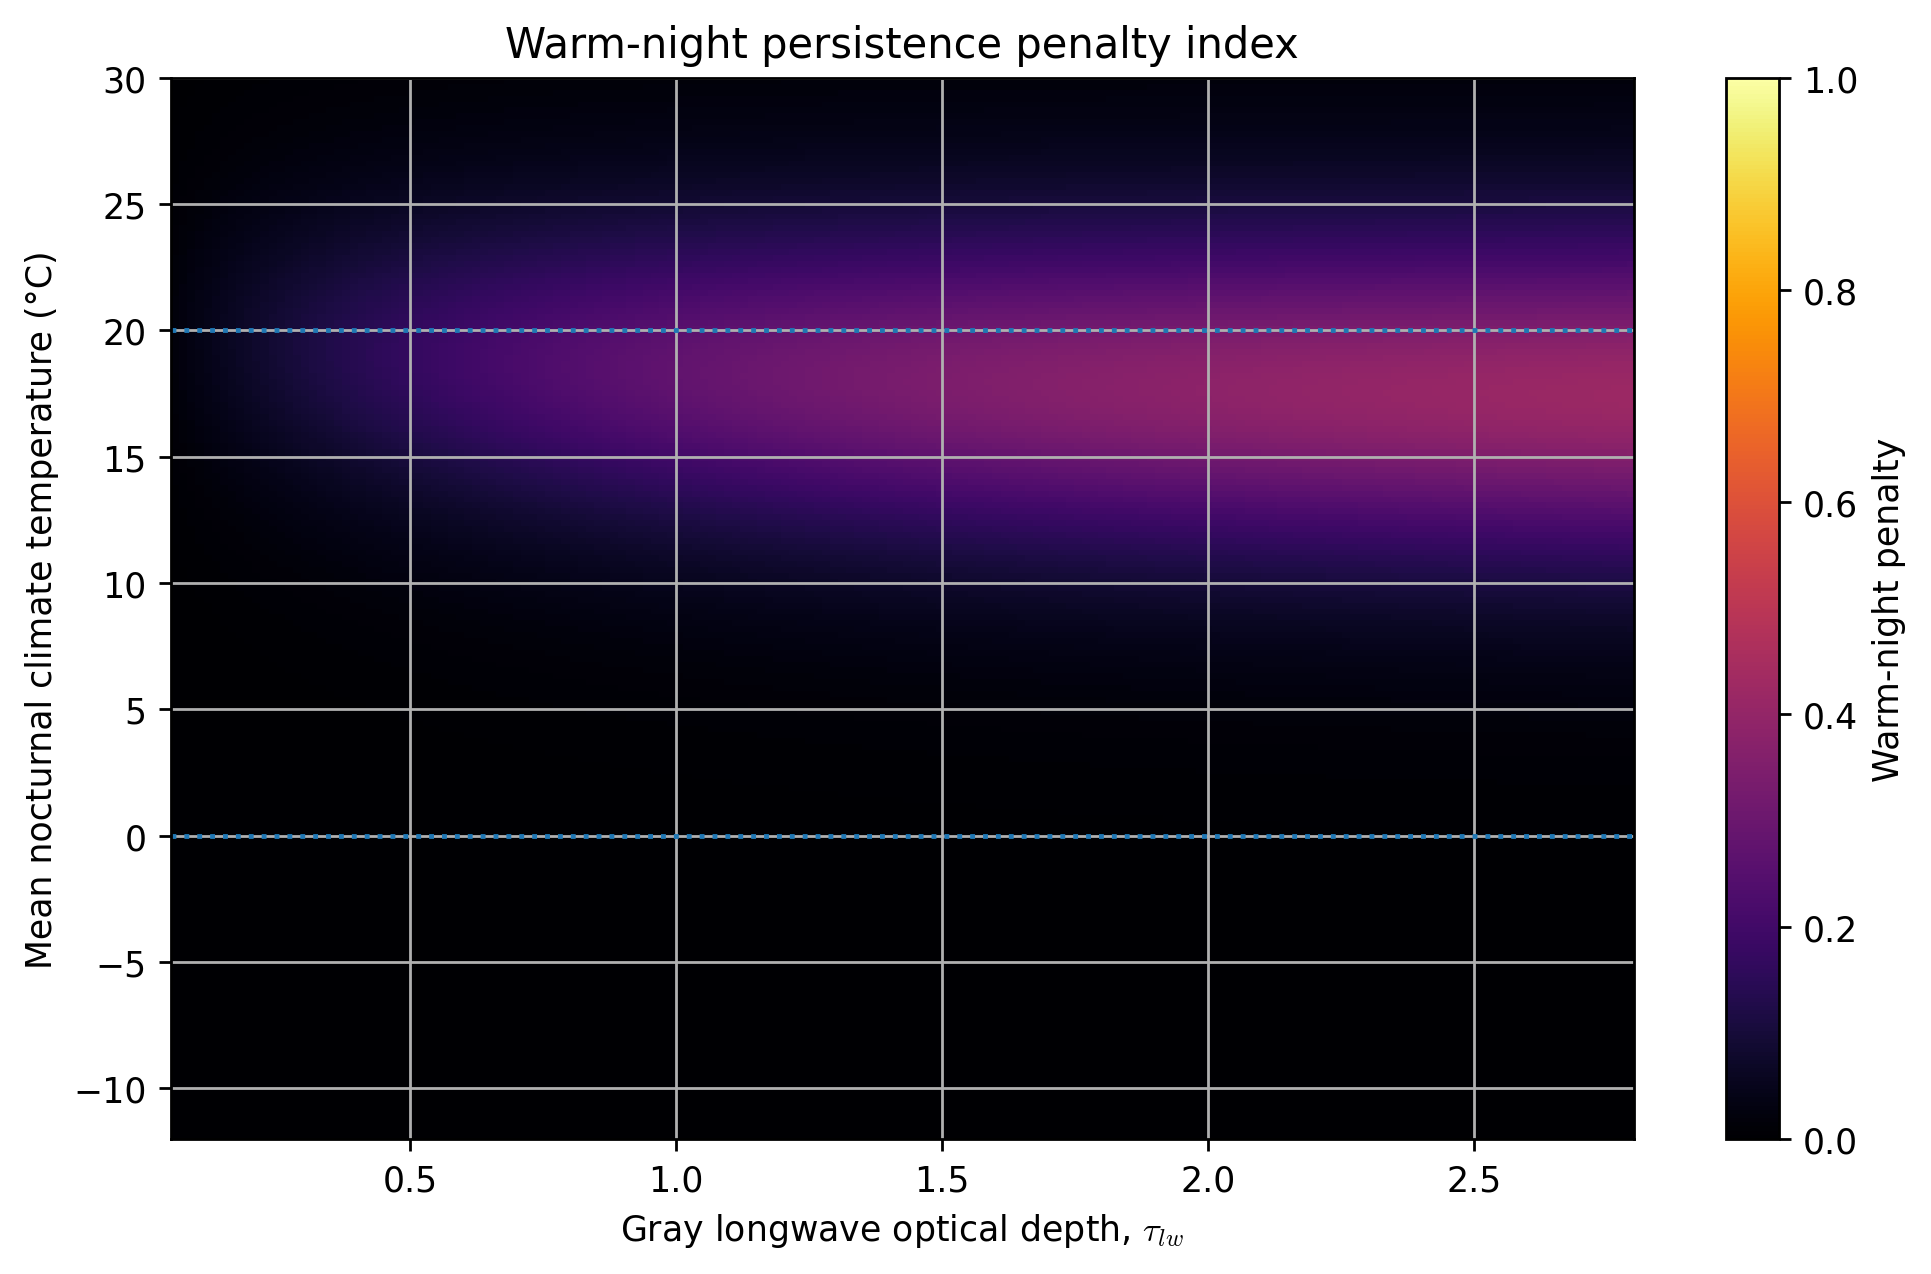

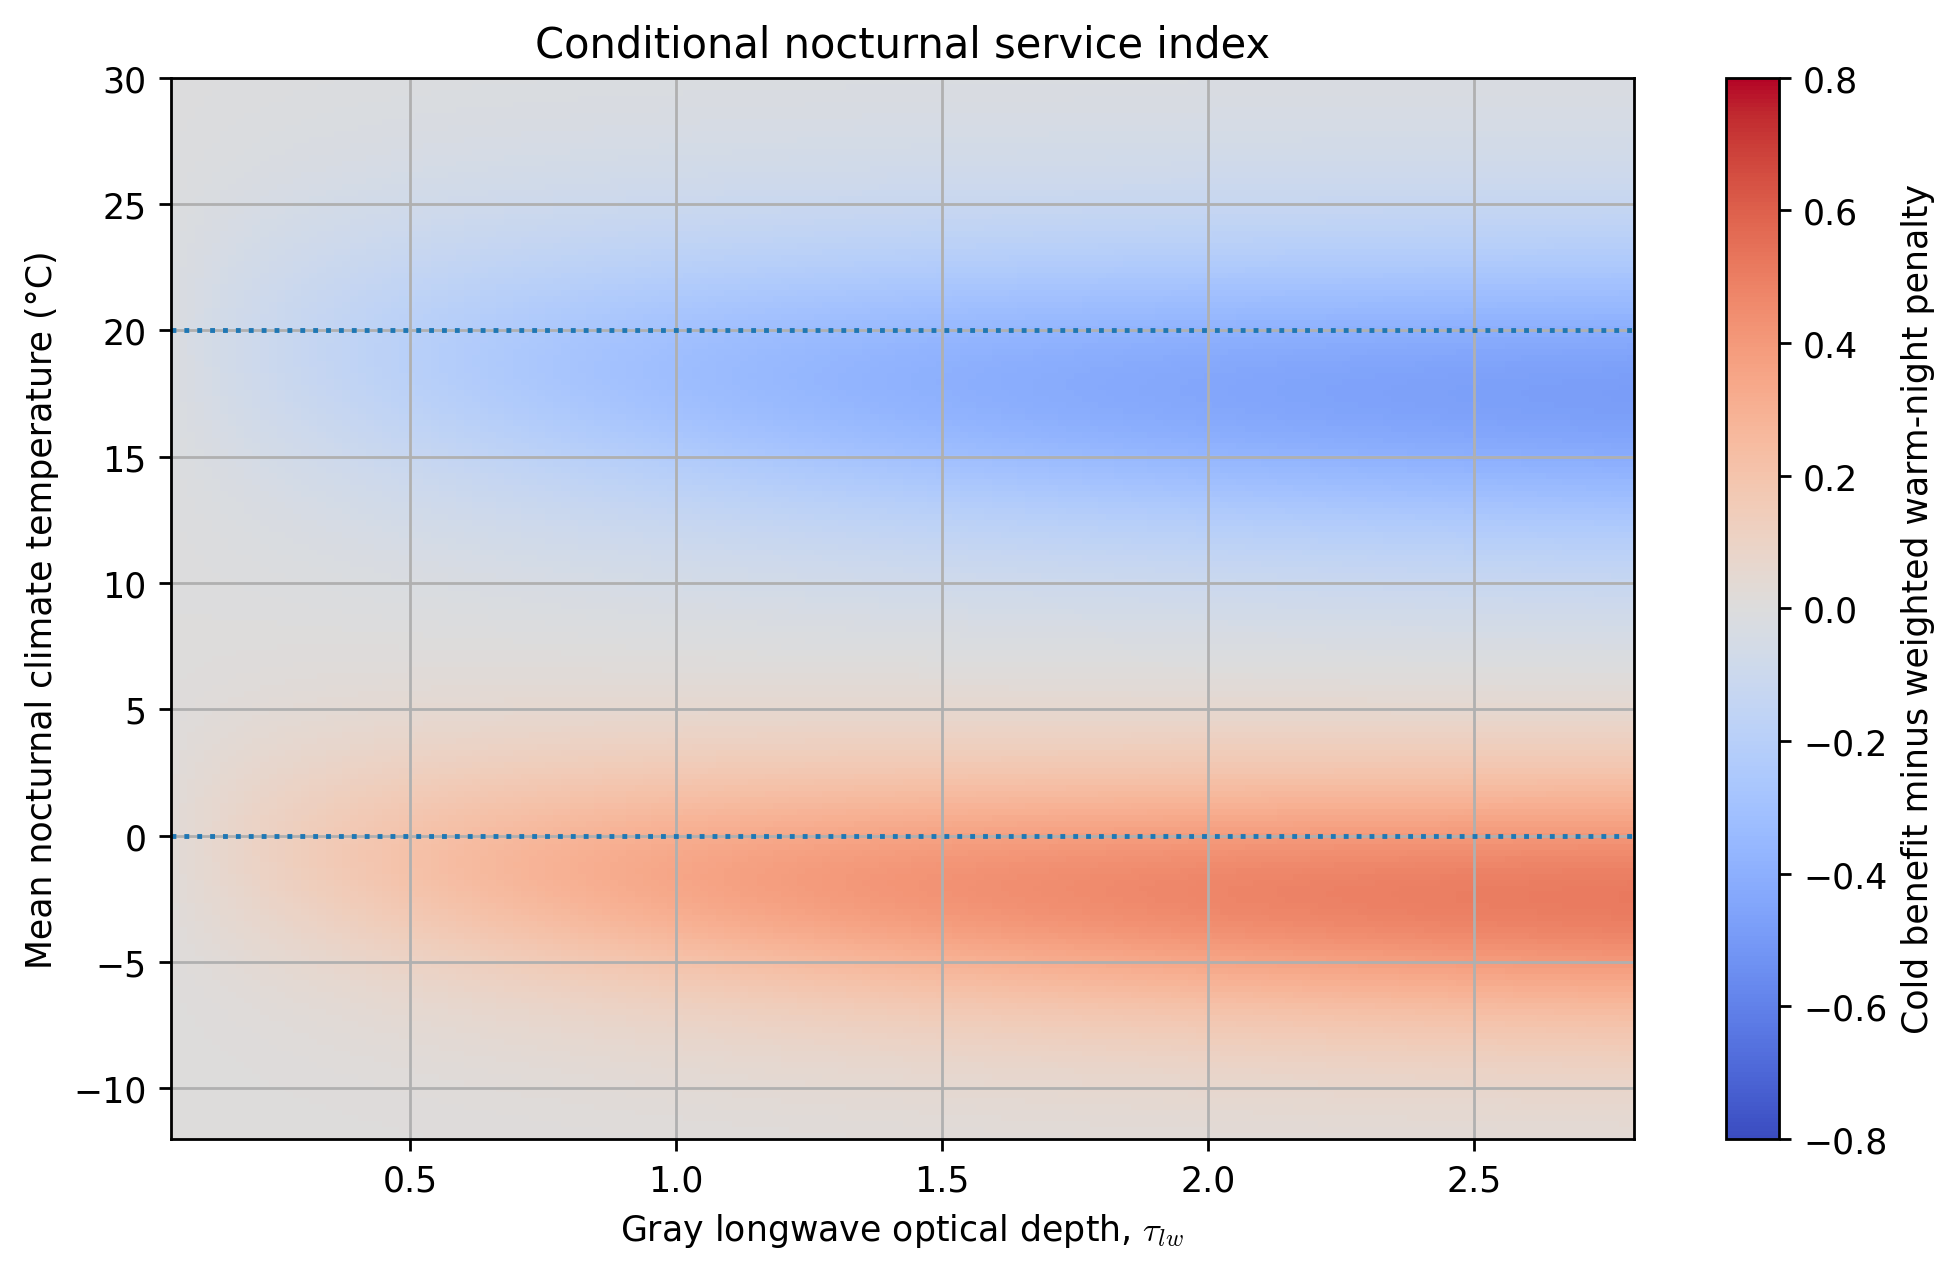

In [6]:
"""Synthesis map for conditional nocturnal greenhouse benefits and penalties.

This cell builds a regime classifier that compares cold-risk buffering against
warm-night persistence. It produces a compact synthesis figure suitable for
turning the visual study into a research-article outline.
"""


import subprocess
import sys
from typing import Final

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit

# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_PACKAGES: Final[bool] = False
MPL_DPI: Final[int] = 250

MEAN_CLIMATE_TEMP_RANGE_C: Final[tuple[float, float]] = (-12.0, 30.0)
LONGWAVE_OPACITY_RANGE: Final[tuple[float, float]] = (0.05, 2.8)
TEMP_POINTS: Final[int] = 180
OPACITY_POINTS: Final[int] = 180

COLD_THRESHOLD_C: Final[float] = 0.0
WARM_THRESHOLD_C: Final[float] = 20.0
COLD_SLOPE_K: Final[float] = 2.2
WARM_SLOPE_K: Final[float] = 2.8
BUFFER_STRENGTH_K: Final[float] = 5.5
BUFFER_SATURATION_SCALE: Final[float] = 1.15
HEAT_STRESS_WEIGHT: Final[float] = 1.15
COLD_BUFFER_WEIGHT: Final[float] = 1.0

# =============================================================================
# SETUP
# =============================================================================


def maybe_install_packages() -> None:
    """Install dependencies if this file is pasted as a fresh Colab cell."""
    if INSTALL_PACKAGES:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "uv"])
        subprocess.check_call(
            [
                "uv",
                "pip",
                "install",
                "--system",
                "-q",
                "numpy",
                "pandas",
                "matplotlib",
                "scipy",
            ]
        )


def configure_plots() -> None:
    """Configure high-DPI plots for Colab."""
    mpl.rcParams["figure.dpi"] = MPL_DPI
    mpl.rcParams["savefig.dpi"] = MPL_DPI
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["mathtext.fontset"] = "cm"

# =============================================================================
# REGIME INDEX MODEL
# =============================================================================


def opacity_to_buffer_k(opacity: np.ndarray) -> np.ndarray:
    """Map longwave opacity to a saturating nighttime thermal buffer."""
    return BUFFER_STRENGTH_K * (1.0 - np.exp(-opacity / BUFFER_SATURATION_SCALE))


def cold_risk(temp_c: np.ndarray) -> np.ndarray:
    """Smooth probability-like cold-risk index."""
    return expit((COLD_THRESHOLD_C - temp_c) / COLD_SLOPE_K)


def warm_risk(temp_c: np.ndarray) -> np.ndarray:
    """Smooth probability-like warm-night persistence index."""
    return expit((temp_c - WARM_THRESHOLD_C) / WARM_SLOPE_K)


def build_regime_grids() -> tuple[np.ndarray, np.ndarray, dict[str, np.ndarray]]:
    """Build synthesis grids over mean climate temperature and opacity."""
    mean_temp_c = np.linspace(*MEAN_CLIMATE_TEMP_RANGE_C, TEMP_POINTS)
    opacity = np.linspace(*LONGWAVE_OPACITY_RANGE, OPACITY_POINTS)
    opacity_grid, temp_grid = np.meshgrid(opacity, mean_temp_c)

    buffer_k = opacity_to_buffer_k(opacity_grid)
    buffered_temp_c = temp_grid + buffer_k

    cold_before = cold_risk(temp_grid)
    cold_after = cold_risk(buffered_temp_c)
    warm_before = warm_risk(temp_grid)
    warm_after = warm_risk(buffered_temp_c)

    cold_benefit = cold_before - cold_after
    warm_penalty = warm_after - warm_before
    net_index = COLD_BUFFER_WEIGHT * cold_benefit - HEAT_STRESS_WEIGHT * warm_penalty

    grids = {
        "buffer_k": buffer_k,
        "cold_benefit": cold_benefit,
        "warm_penalty": warm_penalty,
        "net_index": net_index,
        "buffered_temp_c": buffered_temp_c,
    }
    return mean_temp_c, opacity, grids


def summarize_regimes(
    mean_temp_c: np.ndarray,
    opacity: np.ndarray,
    grids: dict[str, np.ndarray],
) -> pd.DataFrame:
    """Build a compact table for representative climate regimes."""
    cases = [
        ("high-elevation cold night", -6.0, 1.0),
        ("marginal frost night", 1.0, 1.0),
        ("temperate mild night", 10.0, 1.0),
        ("humid warm night", 22.0, 1.6),
        ("desert warm night", 25.0, 0.5),
    ]
    rows: list[dict[str, float | str]] = []
    for label, temp_target, opacity_target in cases:
        temp_idx = int(np.argmin(np.abs(mean_temp_c - temp_target)))
        opacity_idx = int(np.argmin(np.abs(opacity - opacity_target)))
        rows.append(
            {
                "regime": label,
                "mean_night_C": mean_temp_c[temp_idx],
                "tau_lw": opacity[opacity_idx],
                "buffer_K": grids["buffer_k"][temp_idx, opacity_idx],
                "cold_benefit": grids["cold_benefit"][temp_idx, opacity_idx],
                "warm_penalty": grids["warm_penalty"][temp_idx, opacity_idx],
                "net_index": grids["net_index"][temp_idx, opacity_idx],
            }
        )
    table = pd.DataFrame(rows)
    print("Synthesis-regime table")
    print(table.to_string(index=False, float_format=lambda value: f"{value: .4f}"))
    return table

# =============================================================================
# PLOTTING
# =============================================================================


def plot_grid(
    mean_temp_c: np.ndarray,
    opacity: np.ndarray,
    grid: np.ndarray,
    title: str,
    colorbar_label: str,
    cmap: str,
    vmin: float | None = None,
    vmax: float | None = None,
) -> None:
    """Render a synthesis heat map."""
    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    image = ax.imshow(
        grid,
        origin="lower",
        aspect="auto",
        extent=[
            opacity.min(),
            opacity.max(),
            mean_temp_c.min(),
            mean_temp_c.max(),
        ],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.axhline(COLD_THRESHOLD_C, linewidth=1.4, linestyle=":")
    ax.axhline(WARM_THRESHOLD_C, linewidth=1.4, linestyle=":")
    ax.set_xlabel(r"Gray longwave optical depth, $\tau_{lw}$")
    ax.set_ylabel("Mean nocturnal climate temperature (°C)")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label=colorbar_label)
    plt.tight_layout()
    plt.show()


def plot_all_synthesis_maps(
    mean_temp_c: np.ndarray,
    opacity: np.ndarray,
    grids: dict[str, np.ndarray],
) -> None:
    """Render all synthesis maps."""
    plot_grid(
        mean_temp_c,
        opacity,
        grids["buffer_k"],
        "Parameterized nocturnal thermal buffer from longwave opacity",
        "Temperature buffer (K)",
        "viridis",
    )
    plot_grid(
        mean_temp_c,
        opacity,
        grids["cold_benefit"],
        "Cold-risk reduction index",
        "Cold-risk reduction",
        "YlGnBu",
        0.0,
        1.0,
    )
    plot_grid(
        mean_temp_c,
        opacity,
        grids["warm_penalty"],
        "Warm-night persistence penalty index",
        "Warm-night penalty",
        "inferno",
        0.0,
        1.0,
    )
    plot_grid(
        mean_temp_c,
        opacity,
        grids["net_index"],
        "Conditional nocturnal service index",
        "Cold benefit minus weighted warm-night penalty",
        "coolwarm",
        -0.8,
        0.8,
    )


def main() -> pd.DataFrame:
    """Run the synthesis classifier and return the summary table."""
    maybe_install_packages()
    configure_plots()
    mean_temp_c, opacity, grids = build_regime_grids()
    table = summarize_regimes(mean_temp_c, opacity, grids)
    plot_all_synthesis_maps(mean_temp_c, opacity, grids)
    return table


if __name__ == "__main__":
    results = main()